# Nuclear cost trajectories under uncertain learning — Monte Carlo notebook

**What this notebook does.** The nuclear-learning paper asks: *if the United States committed to a
given nuclear build-out, what would new reactors cost along the way — and what subsidy would it take
to make that build-out happen?* This notebook answers the first half of that question. For each of
six possible US deployment schedules (ranging from modest to very ambitious), it runs a Monte Carlo
simulation — 5,000 random draws of the uncertain quantities that drive nuclear costs — and turns each
draw into a full 2024–2050 cost trajectory for two reactor technologies: **large light-water reactors**
(~1,000 MW each) and **small modular reactors (SMRs)** (~300 MW each).

**What it produces:**

1. **Six conditional cost "fans"** — for each deployment schedule, the range of overnight capital
   cost (OCC), construction duration, and financed capital cost consistent with that schedule.
2. **18 ready-to-run ReEDS cases** — for each schedule, three representative draws (cheap / middle /
   expensive), exported in exactly the file formats the ReEDS electricity-system model reads.
3. **Two paper figures** — a *hindcast* check (does the learning model, run backwards, reproduce
   what actually happened in Korea, France, and the US?) and a *fragmentation* figure (how much more
   expensive is splitting the build program across two technologies instead of concentrating on one?).

**One sentence to keep in mind throughout.** Every cost number in this notebook is **conditional on
its deployment schedule actually happening** — these are *"if the US builds X, costs consistent with
X look like Y"* statements, never predictions of what nuclear will cost. No probability weights are
attached to the schedules, because the paper deliberately does not predict how much nuclear the US
will build. By design, no unconditional cost distribution exists anywhere in this notebook.

**Reader's guide.** Sections are numbered S1–S16. Each opens with a plain-language explanation of
what it does and why the paper needs it; the mathematics follows for readers who want it, and the
one long derivation (S5) is explicitly skippable. Sections S1–S9 build the simulation; S10–S12 turn
it into ReEDS cases; S13–S14 are analysis figures; S15 is the permanent test suite (every check
prints PASS or a report); S16 records metadata for reproducibility.

> **Authority note.** This notebook implements the plan in `z-ethan/nuclear-learning-paper-plan.md`
> (v8). It is a re-architected port of the reference notebook `mc_nuclear_smr_learning.ipynb` (v2.4,
> in the `ReEDS-hybrid-plant` repo); where the two disagree, the paper plan wins. The main
> architectural changes: one **independent Monte Carlo per schedule** (no schedule weights, no
> schedule–deployment coupling), a **financing model replicated from ReEDS itself**, and
> **winner-take-all technology selection** computed here rather than left to ReEDS.

## S1 — Setup: paths, reproducibility, and the analysis switches

Housekeeping first. Three things happen here:

1. **Paths are anchored.** Everything is located relative to this notebook's folder, so the notebook
   works no matter which directory it is launched from. `REPO_ROOT` is the ReEDS fork this notebook
   lives inside — the export section (S12) writes files into the fork's input tree, and the financing
   section (S7) reads ReEDS's own financial assumptions from it.
2. **Randomness is controlled.** Every random draw comes from a named, independent stream derived
   from one master seed (`rng_stream("...")`). This fixes a subtle defect of the reference notebook,
   where all draws shared one stream, so *reordering or re-running cells changed the results*. Here,
   the schedule-3 duration draws (say) are identical no matter what ran before them.
3. **Analysis switches are declared up front.** A few methodological choices are still formally open
   in the paper plan (they will be settled at the team regroup). Each is implemented behind a switch
   with a clearly-marked default so the eventual decision is a one-line change, not a rewrite.

In [1]:
import json
import os
import zlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --- Paths: anchored to this notebook's folder, never the launch directory ---
NB_DIR = Path.cwd() if Path.cwd().name == "mc" else Path("z-ethan/mc").resolve()
assert (NB_DIR / "pris_loader.py").exists(), f"notebook folder not found from {Path.cwd()}"
REPO_ROOT = NB_DIR.parent.parent               # the ReEDS-nuclear-learning fork
EXPORTS = NB_DIR / "exports"                   # notebook-local analysis exports
FIGURES = NB_DIR / "figures"                   # paper figures
for d in (EXPORTS, FIGURES):
    d.mkdir(exist_ok=True)

import sys
if str(NB_DIR) not in sys.path:                # make `import pris_loader` work from any launch dir
    sys.path.insert(0, str(NB_DIR))

# --- Reproducibility: one master seed, independent named streams ---
MASTER_SEED = 20260715

def rng_stream(name):
    """An independent, reproducible random generator tied to a label.

    Each named stream is seeded by (master seed, hash of the label), so every
    component of the analysis gets its own private randomness: re-running or
    reordering cells can never change another component's draws.
    """
    return np.random.default_rng(np.random.SeedSequence((MASTER_SEED, zlib.crc32(name.encode()))))

# --- Analysis switches (defaults; each tagged with the paper-plan issue that owns it) ---
# How draws are ranked "cheap to expensive" when picking the P5/P50/P95 cases (S10-S11).
# DEFAULT pending confirmation at the team regroup (paper plan issue 8).
RANKING_FUNCTIONAL = "discounted_schedule_weighted"   # alternatives stubbed in S10

# Whether the financed-cost ranking includes the Investment Tax Credit. Off by default:
# the paper *solves for* the required subsidy, so baking a subsidy into the ranking
# would be circular (S7).
USE_ITC_IN_RANKING = False

# Whether the six schedule MCs share the same random draws ("common random numbers").
# Off per the paper plan (independent MCs); sharing draws would sharpen cross-schedule
# comparisons but is a design change to confirm first.
COMMON_RANDOM_NUMBERS = False

# Path to a finished ReEDS shakedown run, used by the S15 financing cross-check
# (QA10); the check prints SKIPPED if the run directory does not exist.
REEDS_RUN_DIR = REPO_ROOT / "runs" / "utshake_ut_learn"

# Copula correlation set for the parameter draws (S8); "zero"/"moderate"/"strong"
# are compared as a sensitivity in S14.
COPULA_SET = "moderate"

N_DRAWS = 10000                             # draws per schedule (6 schedules = 60,000 total)

# --- Model frame (unchanged from the reference notebook) ---
YEARS = np.arange(2024, 2051)              # annual grid, 2024-2050
T = len(YEARS)
def yi(y):
    """Index of calendar year y in the YEARS grid."""
    return int(np.where(YEARS == y)[0][0])

ANCHOR = 2030          # the anchor year: costs are pinned to known 2030 estimates (S5)
N_BOAK_UNITS = 2.0     # per-vendor experience at the anchor ("BOAK = 2OAK": the 2030 cost
                       # estimate is for a vendor's SECOND unit of a kind - see S5, Step 4)
OMEGA = 1.0 / 3.0      # cross-firm learning fraction: other builders' reactors teach a vendor
                       # about 1/3 as much as its own (Irwin & Klenow 1994 - see S5, Step 2)

# Substitution parameter for the CES generalization of the learning engine (S5, Step 8).
# 0 = the baseline multiplicative model; the sweep brackets a structural assumption.
CES_RHO_GRID = np.array([-2.0, -1.0, 0.0, 1.0])

# Per-technology assumptions: unit size, learning-rate range, 2030 anchor-cost range
# (2022 USD per kW; Abou-Jaoude Table A-1 / NREL ATB 2024)
TECH = {
    "large": {"unit_gw": 1.000, "lr_lo": 0.03, "lr_hi": 0.12,
              "boak_lo": 5250.0, "boak_hi": 7750.0},
    "smr":   {"unit_gw": 0.300, "lr_lo": 0.03, "lr_hi": 0.16,
              "boak_lo": 5500.0, "boak_hi": 10000.0},
}
UNIT_FOREIGN_GW = 1.0  # foreign new builds are treated as 1-GW large reactors

U_GRID = np.linspace(0.0, 1.0, 21)   # grid for the international-deployment position u (S3)

print(f"notebook dir : {NB_DIR}")
print(f"repo root    : {REPO_ROOT}")
print(f"switches     : ranking={RANKING_FUNCTIONAL}, ITC_in_ranking={USE_ITC_IN_RANKING}, "
      f"CRN={COMMON_RANDOM_NUMBERS}, copula={COPULA_SET}, draws/schedule={N_DRAWS}")

notebook dir : C:\Users\ethan\code\research\ReEDS-nuclear-learning\z-ethan\mc
repo root    : C:\Users\ethan\code\research\ReEDS-nuclear-learning
switches     : ranking=discounted_schedule_weighted, ITC_in_ranking=False, CRN=False, copula=moderate, draws/schedule=10000


## S2 — The six deployment schedules

**What this section does.** It defines the six US nuclear deployment schedules the whole paper is
built around, exports them to a single shared file (`US_SCHEDULES.csv` in the ReEDS fork's input
tree — the *single source of truth* that the ReEDS mandate files are regenerated from), and checks
that regeneration against the trajectory files already in the fork.

**Why six schedules, and why these six?** The paper prices deployment ambitions; it does not choose
between them. To cover the whole conversation without duplicating anyone's position, the set takes
**one schedule from each kind of source** that publishes US nuclear outlooks, forming a ladder of
ambition from 117 GW to 400 GW by 2050 (the US fleet today is ~97 GW):

| Schedule | 2050 capacity | What kind of source it is |
|---|---|---|
| **EIA 2026 AEO high** | 117 GW | A *modeled projection* — the US Energy Information Administration's high case |
| **Abou-Jaoude mod** | 134 GW | A *study assumption* — the moderate deployment case of the Idaho National Laboratory cost meta-analysis |
| **IAEA high** | 172 GW | An *intergovernmental outlook* — the International Atomic Energy Agency's high projection |
| **McKinsey GEP 2025** | 200 GW | A *consultancy outlook* — McKinsey's Global Energy Perspective |
| **COP28 tripling pledge** | 300 GW | A *pledge* — the Declaration to Triple Nuclear Energy launched at COP28 (Dubai, 2023), read as tripling the US fleet |
| **2025 EO** | 400 GW | A *policy aspiration* — the 2025 Executive Order target |

Two renames from earlier drafts are locked in here: the tripling pledge is attributed to **COP28**
(the declaration's actual venue — earlier files said "COP29"), and the INL schedule is explicitly the
**moderate** ("mod") variant. The schedules are stored as *capacity indices* (100 = the actual 97 GW
2024 fleet); the export below keeps that convention and documents it in the file header.

**No weights, by design.** The reference notebook attached probability weights to these schedules and
drew among them. The paper removed that: each schedule now gets its own independent Monte Carlo, and
results are always reported *per schedule*. Nothing in this notebook says one schedule is more likely
than another.

> **A 3-GW bookkeeping note (documented, deliberate).** The schedule indices are read as **literal GW
> minus a flat 3 GW** — undoing the rounding of the 97-GW fleet up to index 100 — so every schedule
> starts at exactly the real 2024 fleet and sits exactly 3 GW below its nominal targets (the 2025 EO
> reaches 397 GW in 2050, not 400). This one basis is used everywhere: the plot below, the experience
> counting in S3, and the ReEDS mandate files (whose regeneration script,
> `inputs/nuclear_learning/_generate_cap_trajectories.py`, applies the same subtraction — checked
> below). The 2050 capacities quoted in the table above are the sources' nominal targets.

wrote inputs\nuclear_learning\US_SCHEDULES.csv


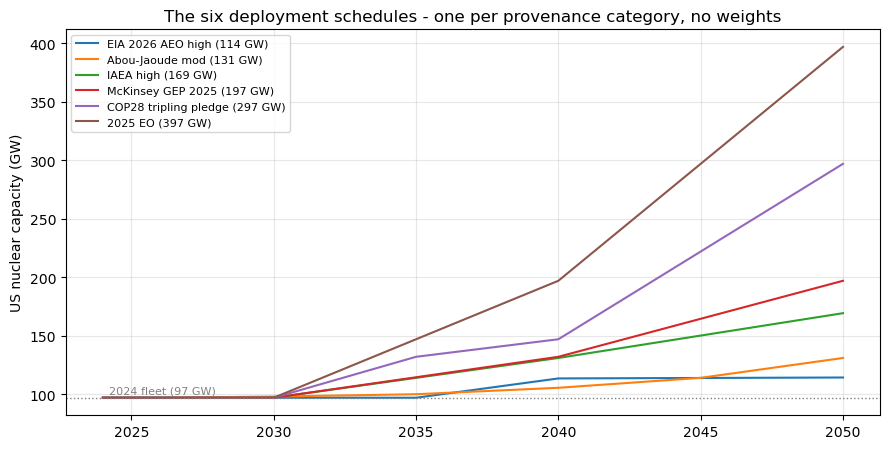

In [2]:
# The locked schedule set: capacity index by year, 2024-2050 (index 100 = 97.0 GW in 2024).
# Values are carried over unchanged from the reference notebook (v2.4 cell 3); only two
# names differ: "COP29 target" -> "COP28 tripling pledge", "Abou-Jaoude" -> "Abou-Jaoude mod".
US_GW_2024 = 97.0
# GW basis used EVERYWHERE (plots, experience counting, and the ReEDS mandate files):
# the index read as literal GW minus a flat 3 GW, undoing the rounding of the 97-GW 2024
# fleet up to index 100. So every schedule sits exactly 3 GW below its nominal targets
# (2025 EO: 397 GW in 2050) and starts at exactly the real 97-GW fleet.
OFFSET_GW = 3.0

US_SCHEDULES = {
    "EIA 2026 AEO high":     [100,100,100,100,100,100,100,100,100,100,100,100,103.3,106.6,109.9,
                              113.2,116.5,116.58,116.66,116.74,116.82,116.9,116.98,117.06,117.14,
                              117.22,117.3],
    "Abou-Jaoude mod":       [100,100,100,100.25,100.5,100.75,101,101.4,101.8,102.2,102.6,103,
                              104.1,105.2,106.3,107.4,108.5,110.2,111.9,113.6,115.3,117,120.4,
                              123.8,127.2,130.6,134],
    "IAEA high":             [100,100,100,100,100,100,100,103.4,106.8,110.2,113.6,117,120.4,123.8,
                              127.2,130.6,134,137.83,141.66,145.49,149.32,153.15,156.98,160.81,
                              164.64,168.47,172.3],
    "McKinsey GEP 2025":     [100,100,100,100,100,100,100,103.5,107,110.5,114,117.5,121,124.5,128,
                              131.5,135,141.5,148,154.5,161,167.5,174,180.5,187,193.5,200],
    "COP28 tripling pledge": [100,100,100,100,100,100,100,107,114,121,128,135,138,141,144,147,150,
                              165,180,195,210,225,240,255,270,285,300],
    "2025 EO":               [100,100,100,100,100,100,100,110,120,130,140,150,160,170,180,190,200,
                              220,240,260,280,300,320,340,360,380,400],
}
SCHED_ORDER = list(US_SCHEDULES)             # fixed order: ascending 2050 ambition, 117 -> 400

# Short machine-readable token per schedule - used in ReEDS file names and switch values
SCEN_TOKEN = {
    "EIA 2026 AEO high":     "eia_aeo_high",
    "Abou-Jaoude mod":       "abou_jaoude",
    "IAEA high":             "iaea_high",
    "McKinsey GEP 2025":     "mckinsey",
    "COP28 tripling pledge": "cop28",        # renamed from cop29 (see the markdown above)
    "2025 EO":               "eo2025",
}

for name, idx in US_SCHEDULES.items():
    assert len(idx) == T, name
    assert all(b >= a for a, b in zip(idx, idx[1:])), f"{name}: schedule must be non-decreasing"

# --- Export the single source of truth into the ReEDS input tree ---
sched_out = pd.DataFrame({SCEN_TOKEN[name]: US_SCHEDULES[name] for name in SCHED_ORDER},
                         index=pd.Index(YEARS, name="year"))
US_SCHEDULES_CSV = REPO_ROOT / "inputs" / "nuclear_learning" / "US_SCHEDULES.csv"
header = (
    "# US nuclear deployment schedules - SINGLE SOURCE OF TRUTH (exported by "
    "z-ethan/mc/mc_cost_trajectories.ipynb, section S2)\n"
    f"# Values are capacity indices: 100 = {US_GW_2024} GW (actual 2024 US fleet).\n"
    "# The ReEDS mandate files nuclear_cap_trajectory_{scen}.csv are regenerated from this file by\n"
    "# _generate_cap_trajectories.py, which reads the index as literal GW minus a flat 3 GW\n"
    "# (undoing the 97->100 base-year rounding). cop28 was named cop29 in earlier exports\n"
    "# (the tripling pledge was launched at COP28, Dubai 2023).\n"
)
with open(US_SCHEDULES_CSV, "w", newline="\n") as f:
    f.write(header)
    sched_out.to_csv(f)
print(f"wrote {US_SCHEDULES_CSV.relative_to(REPO_ROOT)}")

# --- Plot: the ambition ladder in GW (literal GW minus the 3-GW rounding offset) ---
fig, ax = plt.subplots(figsize=(9, 4.6))
for name in SCHED_ORDER:
    ax.plot(YEARS, np.array(US_SCHEDULES[name]) - OFFSET_GW,
            label=f"{name} ({US_SCHEDULES[name][-1] - OFFSET_GW:.0f} GW)")
ax.axhline(US_GW_2024, ls=":", c="gray", lw=1)
ax.text(2024.2, US_GW_2024 + 4, "2024 fleet (97 GW)", fontsize=8, color="gray")
ax.set_ylabel("US nuclear capacity (GW)")
ax.set_title("The six deployment schedules - one per provenance category, no weights")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [3]:
# Regeneration parity check: the mandate trajectory files already in the ReEDS fork must
# equal what _generate_cap_trajectories.py would produce from the export above -
# MW = (index - 3.0) * 1000, read as literal GW. A mismatch means a transcription drift
# between this notebook and the fork inputs, which would silently decouple the costs
# from the mandates they are supposed to be consistent with.
TRAJ_DIR = REPO_ROOT / "inputs" / "nuclear_learning"

problems = []
for name in SCHED_ORDER:
    token = SCEN_TOKEN[name]
    path = TRAJ_DIR / f"nuclear_cap_trajectory_{token}.csv"
    if token == "cop28" and not path.exists():
        path = TRAJ_DIR / "nuclear_cap_trajectory_cop29.csv"   # pre-rename filename
    rows = [ln.split(",") for ln in path.read_text().splitlines() if not ln.startswith("*")]
    on_file = {int(y): float(mw) for y, mw in rows}
    expected = {int(y): round((v - OFFSET_GW) * 1000.0, 1)
                for y, v in zip(YEARS, US_SCHEDULES[name])}
    if on_file != expected:
        diffs = {y: (on_file.get(y), expected[y]) for y in expected if on_file.get(y) != expected[y]}
        problems.append(f"{name} ({path.name}): {diffs}")
assert not problems, "trajectory parity check FAILED:\n" + "\n".join(problems)
print("trajectory parity check PASSED: all six ReEDS mandate files match the schedule export "
      f"(basis: literal GW minus {OFFSET_GW:.0f} GW, x1000 to MW)")

trajectory parity check PASSED: all six ReEDS mandate files match the schedule export (basis: literal GW minus 3 GW, x1000 to MW)


## S3 — Historical experience: what the world's reactor fleet tells us

**What this section does.** Learning models run on *experience* — counts of reactors built. This
section builds those counts: how many reactors the US and every other world region has built, will
retire, and is committed to building, using unit-by-unit data on all 715 power reactors ever
connected to a grid.

**Where the data comes from.** The IAEA (the UN's nuclear agency) maintains PRIS, the authoritative
database of every power reactor in the world. We use its 2025 annual extract (RDS-2, data through
31 Dec 2024), stored here as `rds2_2025_units.csv` and loaded by the small helper module
`pris_loader.py`. The extract reproduces the IAEA's own published totals exactly (417 operational /
62 under construction / 23 suspended / 213 shut down), which is asserted below — if the data file
were edited or corrupted, this cell would fail loudly.

**Three ideas to follow in the code:**

1. **Builds, not net capacity.** If a region's capacity is flat but old plants retire, new plants
   must be getting built — and those builds create learning. So gross builds are recovered from the
   *retirement identity*: builds = capacity change + retirements, with retirements rolled forward
   from each unit's actual grid-connection date under an assumed lifetime — calibrated here to
   the IAEA's own case construction (~65-yr lives in the Low world, ~70-yr in the High: the
   uniform lives that reproduce RDS-1 2025's 156 / ~81 GW of 2024-fleet retirements by 2050).
2. **The committed pipeline replaces guesses through 2030.** Over its real visibility horizon we
   know which units are actually under construction, so those real units replace the interpolated
   path (avoiding double-counting). The latest observed construction starts (2024) plus the
   72-month lead make the pipeline structurally zero after 2030.
3. **Foreign experience counts for less, per the spillover weights θ.** A reactor built in China
   teaches US vendors something, but much less than a US build. Each region gets a transfer
   coefficient θ (from cross-country knowledge-flow estimates), and foreign deployment between the
   IAEA's Low and High projections is positioned by a drawn number **u** (0 = Low world, 1 = High
   world) — one of the Monte Carlo's uncertain inputs.

> **A bookkeeping note.** Experience counting uses the same GW basis as everything else (S2):
> the schedule index read as literal GW minus the flat 3-GW rounding offset. The builds counted
> here are therefore exactly the builds the ReEDS mandate will enforce — costs and constraint
> share one deployment path by construction.

In [4]:
# Non-US regional milestones (GW): 2024, 2030 Low/High, 2040 Low/High, 2050 Low/High
# (IAEA RDS-1 2025 projections + WNA/CNA). Regions: Canada, South America, Western Europe,
# Eastern Europe, Africa, West Asia, South Asia, Central+East Asia, Southeast Asia, Oceania.
REGION_MILESTONES = {
    "CA":  (12.7, 12.7, 12.7, 18.8, 23.0, 30.0, 63.7),
    "SAM": (5.1, 5, 5, 8, 11, 8, 20),
    "WEU": (95.4, 86, 92, 81, 114, 68, 136),
    "EEU": (53.6, 57, 57, 58, 82, 68, 103),
    "AF":  (1.9, 4, 5, 7, 12, 12, 30),
    "WA":  (5.8, 11, 11, 12, 20, 15, 35),
    "SA":  (11.1, 18, 22, 25, 43, 45, 85),
    "CEA": (94.5, 136, 144, 215, 264, 242, 328),
    "SEA": (0, 0, 0, 3, 7, 4, 18),
    "OC":  (0, 0, 0, 0, 0, 0, 2),
}
# Kim & Verdolini (2023)-derived knowledge-spillover ceilings (US as recipient)
THETA_KV = {"CA": 0.28, "SAM": 0.14, "WEU": 0.17794117647, "EEU": 0.1325, "AF": 0.16688725490,
            "WA": 0.13375, "SA": 0.185, "CEA": 0.135, "SEA": 0.16583333, "OC": 0.18}
REGIONS = list(THETA_KV.keys())

import pris_loader as pl

PRIS_UNITS = pl.load_units(str(NB_DIR / "rds2_2025_units.csv"))
_milestones_2024 = {r: REGION_MILESTONES[r][0] for r in REGIONS} | {"US": US_GW_2024}
_issues = pl.validate_units(PRIS_UNITS[PRIS_UNITS["status"] == "operational"], _milestones_2024)
assert not _issues, _issues   # QA1: the data file must reproduce the IAEA's own totals

# Operational fleet (basis of the retirement identity) and the under-construction pipeline
FLEET = PRIS_UNITS[PRIS_UNITS["status"] == "operational"]
UC_UNITS = PRIS_UNITS[PRIS_UNITS["status"] == "under construction"]

def retirement_flow_gw(key, life_yr):
    """GW retiring per model year, from each unit's real grid-connection date + a lifetime rule."""
    return pl.retirement_schedule(FLEET, pd.Index(YEARS), lifetime_years=life_yr,
                                  region=key).to_numpy()

# Committed pipeline 2025-2030: real under-construction units (57 of 62 lack planned grid
# dates in RDS-2 and are estimated at construction start + 72 months). 2030 is the pipeline's
# real visibility horizon - the latest RDS-2 construction starts are 2024 - so it is
# structurally zero afterwards; and because post-anchor experience counting zeroes every year
# <= ANCHOR, the pipeline is inert for the learning stocks (kept as the documented
# committed-build anchor of the pre-2031 path).
PIPE_END = 2030
PIPELINE_GW = {r: pl.committed_pipeline(UC_UNITS[UC_UNITS["region"] == r],
                                        pd.Index(np.arange(2025, PIPE_END + 1)),
                                        lead_time_months=72).to_dict()
               for r in REGIONS}

# Historical experience base (for the "full-stock" convention, S5 Step 6): units EVER
# grid-connected. Under-construction units are excluded: 5 of them (Angra-3, Rajasthan-7,
# Kursk 2-1/2-2, Leningrad 2-3) carry PLANNED grid dates, which are not completed experience.
_ever = PRIS_UNITS[(PRIS_UNITS["status"] != "under construction")
                   & PRIS_UNITS["grid_connection"].notna()]
HIST_UNITS = {r: int((_ever["region"] == r).sum()) for r in REGIONS + ["US"]}

US_LICENSE_LIFE = 80.0   # yr - US subsequent-license-renewal trend; ~0 US retirements before 2050
ONE_FACTOR_DELTA = 0.0   # bounded regional noise on u (0 = one global u; variance-conservative)

print(f"PRIS fleet loaded: {len(FLEET)} operational, {len(UC_UNITS)} under construction "
      f"(validated against RDS-2 published totals and RDS-1 2024 milestones)")

PRIS fleet loaded: 417 operational, 62 under construction (validated against RDS-2 published totals and RDS-1 2024 milestones)


In [5]:
# Precompute the deployment-derived experience stocks that the OCC engine consumes.
def net_path_gw(region, u):
    """Regional net capacity path: interpolate the 2024/2030/2040/2050 milestones, positioned
    between Low and High by the global deployment draw u."""
    c = REGION_MILESTONES[region]
    vals = [c[0], c[1] + u*(c[2]-c[1]), c[3] + u*(c[4]-c[3]), c[5] + u*(c[6]-c[5])]
    return np.interp(YEARS, [2024, 2030, 2040, 2050], vals)

def gross_additions_gw(region, u):
    """The retirement identity: builds = max(0, capacity change + retirements); the committed
    pipeline REPLACES the interpolated path through PIPE_END = 2030 (real units; structurally
    zero after 2030, so it only shapes the pre-anchor record - see the S3 note)."""
    dnet = np.diff(net_path_gw(region, u), prepend=net_path_gw(region, u)[0])
    # Lifetimes are COUPLED to u because the IAEA builds its cases that way (low case: 156 GW
    # of the 2024 fleet retired by 2050; high case: LTO holds retirements to ~81 GW). 65/70-yr
    # uniform lives reproduce those totals from the RDS-2 vintages; the previous 60+20u
    # bracket retired 233/4 GW - roughly double the IAEA's own spread (recalibrated 2026-08-05).
    ret = retirement_flow_gw(region, 65.0 + 5.0*u)    # Low world <-> ~65-yr lives, High <-> ~70-yr
    g = np.clip(dnet + ret, 0.0, None)
    pipe_mask = YEARS <= PIPE_END
    g[pipe_mask] = [PIPELINE_GW[region].get(int(y), 0.0) for y in YEARS[pipe_mask]]
    return g

def post_anchor_cum(flow):
    """Cumulative builds counted from the 2030 anchor, END-of-year basis (experience before
    2030 is handled by the anchor convention, S5 Step 6). The one-year completion lag - a
    year's builds price only LATER years - is applied at the pricing boundary (lag1 in S5),
    so this stays a true cumulative for accounting (GW_ADDITIONS, mandate parity)."""
    x = flow.copy()
    x[YEARS <= ANCHOR] = 0.0
    return np.cumsum(x)

# Foreign stocks on the u grid: REGION_STOCK[r][gi] = cumulative post-anchor units at u = U_GRID[gi]
REGION_STOCK = {}
for r in REGIONS:
    m = np.empty((len(U_GRID), T))
    for gi, u in enumerate(U_GRID):
        m[gi] = post_anchor_cum(gross_additions_gw(r, u)) / UNIT_FOREIGN_GW
    REGION_STOCK[r] = m

# US gross new-build units per schedule and technology (80-yr US life => retirements ~0)
US_RET = retirement_flow_gw("US", US_LICENSE_LIFE)
USN_NEW = {}     # USN_NEW[tech][schedule name] -> (T,) cumulative post-anchor new units
for tech in TECH:
    USN_NEW[tech] = {}
    for name in SCHED_ORDER:
        cap = np.array(US_SCHEDULES[name], float) - OFFSET_GW    # same GW basis as the mandate files
        dnet = np.diff(cap, prepend=cap[0])
        USN_NEW[tech][name] = post_anchor_cum(np.clip(dnet + US_RET, 0.0, None)) / TECH[tech]["unit_gw"]

print("US new-build units by 2050, per schedule (large / SMR):")
for name in SCHED_ORDER:
    print(f"  {name:22s} {USN_NEW['large'][name][-1]:6.0f} large   "
          f"{USN_NEW['smr'][name][-1]:6.0f} SMR")

US new-build units by 2050, per schedule (large / SMR):
  EIA 2026 AEO high          21 large       69 SMR
  Abou-Jaoude mod            36 large      121 SMR
  IAEA high                  76 large      252 SMR
  McKinsey GEP 2025         103 large      345 SMR
  COP28 tripling pledge     203 large      678 SMR
  2025 EO                   303 large     1011 SMR


## S4 — What we treat as uncertain

**What this section does.** Nothing computational — it is the reference card for every random
quantity the Monte Carlo draws, with the basis for each choice. If you read one table in this
notebook, read this one.

**How to read it.** Each draw of the Monte Carlo picks one value for every row below; together those
values define one internally consistent "world," and the model turns that world into cost
trajectories for both technologies at once. Uniform distributions are a deliberate low-information
choice — the empirical literature on nuclear learning rates spans an order of magnitude, so
pretending to know more than a range would be false precision.

| Input | Distribution | Basis |
|---|---|---|
| Learning rate, large | U(3%, 12%), shared learning latent | **Firm-level** rate (Abou-Jaoude eq. 12 convention; effective industry rate ≈ 1.3×LR). Brackets Abou-Jaoude's 8%; low end reflects the weak/negative empirical record (Grubler 2010; Eash-Gates et al. 2020); high end reflects standardized-program experience (Lovering et al. 2016; Barakah) |
| Learning rate, SMR | U(3%, 16%), comonotone with large (same latent) | Firm-level; brackets Abou-Jaoude's 9.5% and the SMR literature span (~5–15%, all assumptions — no empirical SMR learning rate exists) |
| BOAK OCC anchor (2030 cost) | large: U($5,250, $7,750)/kW; SMR: U($5,500, $10,000)/kW, comonotone across techs | Abou-Jaoude Table A-1 / ATB 2024 (2022 USD) |
| Spillover scale s | U(0, 1) × Kim & Verdolini θ vector | 0 = autarky; 1 = full patent-flow ceilings (the K&V estimates cover wind/solar/fossil, not nuclear — hence the scale draw) |
| Global deployment position u | U(0, 1) between IAEA Low and High | Scenario envelope treated as support — a low-information convention that likely understates tail risk (documented). u also positions foreign fleet lifetimes (65 → 70 yr, the retirement assumptions embedded in the IAEA cases themselves) |
| Vendor count m | Discrete U{4,…,8} | Abou-Jaoude's 4 to the current 7+ US vendors |
| Experience-base convention c | tiny-base / full-stock, 50/50 | Structural (model-form) uncertainty: where on its curve large nuclear sits at the (unchanged) BOAK anchor. US history counts for **large only** — the SMR LR range already embeds prior-LWR benefits, and crediting LWR history to SMRs would be cross-tech spillover, which is zero by convention (S5 Steps 6/D8′) |
| Channel-substitution ρ_CES | Discrete uniform over {−2, −1, 0, 1} | Structural axis (S5 Step 8): the multiplicative aggregation pins σ = 1 by convention, not estimation; the sweep brackets the assumption (Nordhaus 2014) |
| Duration scenario position λ | U(0, 1) between INL optimistic and moderate curves | INL/RPT-25-84701 (engineering basis) |
| Duration project noise z | One persistent lognormal draw per path (σ from the 21-unit panel residual) | The realized dispersion of 2009–2024 projects (scandal, bankruptcy, pandemic) keeps slow outcomes in view |

**What changed from the reference notebook (v2.4).** The *US schedule* row is gone: the schedule is
no longer drawn. Each of the six schedules gets its own complete Monte Carlo (10,000 draws each), and
the schedule weights and the schedule–u rank-coupling were removed by design — the paper prices
deployment ambitions; it does not weight them. The deployment draw u is sampled identically and
independently in all six MCs, over the full IAEA envelope.

## S5 — The OCC engine: how deployment becomes cost

**What this section does.** It defines the functions that turn a drawn world plus a deployment
schedule into overnight-cost trajectories. This is the heart of the notebook.

**The idea in plain language.** Costs fall as builders repeat. The engine tracks two kinds of
repetition separately for a representative US vendor:

- **Own experience** — reactors of the vendor's own design, built by its own teams. Each *doubling*
  of this stock cuts cost by the learning rate LR (say 8%).
- **Everyone else's experience** — the other US vendors' reactors, plus (discounted by the θ
  weights) foreign reactors. Doubling this stock cuts cost by only about a third as much (ω·LR) —
  the classic empirical finding that firms learn far more from their own output than from
  competitors'.

Costs are *anchored* at 2030: published 2030 cost estimates (the "BOAK" anchor drawn in S4) pin the
curve's level, and learning moves costs relative to that anchor. So the model never needs to know
the unknowable "cost of the very first unit" — only how much repetition has happened since 2030.

The full derivation below (12 steps, D1–D12) builds this up from Wright's 1936 learning curve with
every assumption cited, including the CES generalization that treats the *combination rule* between
the two experience channels as an uncertain structural choice. **It is reference material — skip it
on first read**; the code after it is short and the docstrings restate what matters.

### Derivation of the OCC equation, from first principles

This section derives the engine equation step by step, assuming comfort with algebra and logarithms but **no economics background**. Variables are defined as they appear and collected in a table at the end; every equation is cited to its source. Throughout, "cost" means overnight capital cost (OCC, \$/kW in 2022 USD, excluding financing) and a "unit" is one completed reactor of the technology class being modeled.

#### Step 1 — Wright's law: cost falls by a fixed fraction per doubling of experience

The empirical starting point, first documented in aircraft manufacturing: **each time cumulative production doubles, unit cost falls by a roughly constant percentage** (Wright 1936). That percentage is called the *learning rate*, LR (terminology per Rubin et al. 2015). Writing $C(N)$ for the cost of the next unit after $N$ units have been built:

$$C(2N) = (1-\mathrm{LR})\,C(N) \tag{D1}$$

*(Wright 1936.)* To turn D1 into a formula, count doublings. If $N$ is $k$ doublings past a reference point $N_{\mathrm{ref}}$, then $k = \log_2(N/N_{\mathrm{ref}})$, and applying D1 $k$ times:

$$C(N) = C(N_{\mathrm{ref}})\,(1-\mathrm{LR})^{\log_2(N/N_{\mathrm{ref}})} = C(N_{\mathrm{ref}})\left(\frac{N}{N_{\mathrm{ref}}}\right)^{b}, \qquad b = \log_2(1-\mathrm{LR}) \tag{D2}$$

*(Wright 1936; the "experience curve" convention in energy analysis per IEA 2000.)* The last step uses the identity $a^{\log_2 x} = x^{\log_2 a}$ — take $\log_2$ of both sides; each equals $\log_2 a \cdot \log_2 x$. The exponent $b$ is negative: at LR = 8%, $b = \log_2(0.92) = -0.120$. Note that *doublings* do all the work — going from 2 to 4 units buys the same fractional cost reduction as going from 4,000 to 8,000 — which is why learning curves flatten so dramatically in absolute terms.

#### Step 2 — Not all units teach equally: own experience vs. other firms'

Using industry-total $N$ in D2 silently assumes a competitor's reactor teaches a vendor as much as its own. The classic empirical test (semiconductor manufacturing) found otherwise: **firms learn roughly three times as much from their own cumulative output as from other firms'** (Irwin & Klenow 1994). This splits experience into two stocks per vendor — own units $O$ and all other firms' units $A$ — each with its own exponent:

$$C = K \cdot O^{\,\log_2(1-\mathrm{LR})} \cdot A^{\,\log_2(1-\omega\mathrm{LR})}, \qquad \omega = \tfrac{1}{3} \tag{D3}$$

*(The ⅓ finding — and that spillovers cross national borders about as readily as they pass between domestic firms: Irwin & Klenow 1994. Their estimation is on price changes; the two-stock power-law rendering and the "(1 − LR/3) per doubling of others' units" implementation used here follow Abou-Jaoude et al. 2024, eq. (12).)* Reading D3: doubling your **own** stock cuts your cost by (1 − LR); doubling **everyone else's** stock cuts it by only (1 − ωLR) = (1 − LR/3). $K$ is an unknown constant (the first-unit cost scale) that Step 4 eliminates.

#### Step 3 — An equal m-vendor market: Abou-Jaoude's eq. (12), generalized

Abou-Jaoude et al. (2024) model the US advanced-reactor market as $m$ identical vendors with equal market shares (they fixed $m = 4$). If the industry builds $N$ units in total, each vendor builds $N/m$ of them, so in D3: $O = N/m$ and $A = (m-1)N/m$. Substituting gives their eq. (12) (printed in the report for $m=4$):

$$f(N) = \frac{1}{1-\mathrm{LR}}\,(1-\mathrm{LR})^{\log_2(N/4)}\,(1-\mathrm{LR}/3)^{\log_2(3N/4)} \tag{D4}$$

*(Abou-Jaoude et al. 2024, eq. (12).)* This notebook generalizes the hard-coded 4 to a drawn $m \in \{4,\dots,8\}$ — same equation with $N/4 \to N/m$ and $3N/4 \to (m-1)N/m$.

#### Step 4 — Anchoring: swap the unknown constant for the known 2030 cost

We never know $K$, but we do have 2030 **BOAK** cost estimates (Abou-Jaoude Table A-1; ATB 2024). Their anchor convention is *BOAK = 2OAK*: BOAK is the cost of a vendor's **second** unit (Abou-Jaoude et al. 2024, eq. (10)) — note this is a *vendor-level* statement. So at the 2030 anchor the representative vendor has $O_0 = 2$ own units and, in a symmetric market where every vendor is at the same point, the other $m-1$ vendors contribute $A_0 = 2(m-1)$. Dividing D3 at time $t$ by D3 at 2030 cancels $K$:

$$\frac{C(t)}{\mathrm{BOAK}} = \left(\frac{O(t)}{O(2030)}\right)^{\log_2(1-\mathrm{LR})}\left(\frac{A(t)}{A(2030)}\right)^{\log_2(1-\omega\mathrm{LR})} \tag{D5}$$

With $N^{US}(t)$ post-2030 gross US builds (from S3) split equally, $O(t) = 2 + N^{US}(t)/m$ and $A(t) = 2(m-1) + (m-1)N^{US}(t)/m$. Both ratios then equal $1 + N^{US}(t)/2m$, so the domestic-only model collapses to:

$$\frac{C(t)}{\mathrm{BOAK}} = \Big[(1-\mathrm{LR})(1-\omega\mathrm{LR})\Big]^{\log_2\!\left(1 + N^{US}(t)/2m\right)} \tag{D6}$$

Two consequences worth internalizing:
- **LR is a firm-level rate.** When the whole fleet doubles, every stock doubles, so industry-level cost falls by $(1-\mathrm{LR})(1-\omega\mathrm{LR})$ per fleet doubling — an effective industry learning rate of $1-(1-\mathrm{LR})(1-\omega\mathrm{LR}) \approx 1.3\,\mathrm{LR}$. Quoting the firm and industry rates interchangeably is a factor-of-1.3 error.
- **The anchor must be per-vendor for the market split to matter.** Suppose instead you pooled experience into one stock scaled by a market-structure factor, $E = \kappa\,(2 + N^{US})$. Then $E(t)/E(2030) = (2+N^{US})/2$ and $\kappa$ cancels — anchoring erases any pure *level* factor. In D6 the split survives only because $m$ sits *inside* the stock ($N^{US}/m$ accumulating against the fixed per-vendor base of 2). This is why an earlier revision of the reference notebook showed no vendor-count sensitivity.

#### Step 5 — International spillover: θ-weighted foreign units join the cross-firm stock

Foreign reactors also teach US vendors, but less than domestic ones: knowledge crosses borders imperfectly. Each region $r$'s post-2030 gross builds $N_r(t)$ are weighted by a transfer coefficient $\theta_r \in [0,1]$, derived from patent-citation knowledge-flow estimates (Kim & Verdolini 2023, processed into the θ vector in the project workbook), and scaled by a drawn factor $s \in [0,1]$ because those estimates cover wind/solar/efficient-fossil — not nuclear:

$$S^{KV}(t) = \sum_r \theta_r\,N_r(t), \qquad \text{entering the model as } s\,S^{KV}(t) \tag{D7}$$

*(Additive weighted "effective experience" stocks are the standard multi-region convention in energy-system models: IEA 2000; Barreto & Kypreos 2004.)* Foreign vendors are, from a US vendor's perspective, simply more "other firms" — so $s\,S^{KV}$ is added to the cross-firm stock $A$, never to $O$. Two properties follow. First, foreign experience can never deliver more than $(1-\omega\mathrm{LR})$ per doubling, consistent with the evidence that nuclear learning is largely firm- and design-specific (Zimmerman 1982; Lester & McCabe 1993; Berthélemy & Escobar-Rangel 2015). Second, the international term is deliberately **not** given its own multiplicative factor: a third power law anchored on its own small base would multiply in another complete learning curve and double-count cheap early doublings.

#### Step 6 — How much experience exists at the anchor? A structural convention

There are two defensible answers to "what has a vendor already learned by 2030?", and the gap between them is large, so both are carried as a drawn convention flag $c \in \{0,1\}$ (50/50):

- **Tiny base** ($c=0$): a genuinely new design restarts its curve — the vendor's base is just its 2 BOAK units (Abou-Jaoude et al. 2024 convention).
- **Full stock** ($c=1$): reactor-building capability is generic, so the historical record counts — the standard experience-curve convention of accumulating from the technology's origin (IEA 2000; Rubin et al. 2015). Each vendor inherits its share $H^{US}/m$ of the ~140 historical US units, and the cross-firm stock inherits the θ-weighted historical world stock $H^{KV} = \sum_r \theta_r H_r$.

$$O_0 = 2 + c\,\frac{H^{US}}{m}, \qquad A_0 = (m-1)\,O_0 + s\,c\,H^{KV} \tag{D8}$$

**Technology asymmetry (D8′).** The convention describes *where each technology sits on its own
learning curve at the shared BOAK anchor* — it never changes the anchor cost itself. And the US
historical fleet is ~140 **large light-water reactors**; no SMR has ever been built. So $H^{US}$
enters D8 **for large reactors only**: under full-stock, large nuclear sits at the flat end of its
curve (mature — most of its learning is already banked, as the Vogtle-era record suggests), while
SMRs keep their 2-unit base and stay at the steep start under *both* conventions. Two reasons SMRs
get no share of the US stock: (i) the drawn SMR learning-rate range (3–16%) comes from estimates
grounded in real-world build experience, so any benefit SMRs derive from prior LWR construction is
already embedded in those rates — adding the stock would double-count it; (ii) crediting LWR history
to SMRs would be a domestic cross-technology spillover, which this model sets to zero by convention.
The θ-weighted *foreign* historical stock $H^{KV}$ still enters the SMR cross-firm channel under
full-stock (world reactor experience teaches SMR vendors a little, at the discounted rate ω·LR),
exactly as it does for large. A consequence worth noting: full-stock worlds are where large nuclear
is *most* disadvantaged relative to SMRs — its curve is flat while theirs stays steep.

#### Step 7 — Assemble

Putting D5–D8 together, for Monte Carlo draw $d$ (which fixes $\mathrm{LR}_d$, $\mathrm{BOAK}_d$, $m_d$, $s_d$, $c_d$, and the deployment world behind $S^{KV}_d$ — while $N^{US}$ is the *schedule's*, fixed for the whole MC):

$$\boxed{\;\mathrm{OCC}_d(t) = \mathrm{BOAK}_d \left(\frac{O_d(t)}{O_{0,d}}\right)^{\log_2(1-\mathrm{LR}_d)} \left(\frac{A_d(t)}{A_{0,d}}\right)^{\log_2(1-\omega\mathrm{LR}_d)}\;} \tag{D9}$$

$$O_d(t) = O_{0,d} + \frac{N^{US}(t)}{m_d}, \qquad A_d(t) = (m_d-1)\,O_{0,d} + \frac{(m_d-1)}{m_d}N^{US}(t) + s_d\Big(c_d H^{KV} + S^{KV}_d(t)\Big)$$

At $t = 2030$ both parenthesized ratios equal 1 by construction, so $\mathrm{OCC}_d(2030) = \mathrm{BOAK}_d$ exactly for every draw (asserted in S15), and at $s_d = 0$, $c_d = 0$ the model reduces exactly to re-anchored generalized eq. (12), i.e., D6 (also asserted).

**Worked example.** Take $m = 5$ vendors, LR = 8% ($b_{own} = -0.120$, $b_{cross} = \log_2(1-0.08/3) = -0.039$), $s = 0.4$, tiny base ($c=0$), and suppose by 2040 the US has built $N^{US} = 20$ units and the θ-weighted foreign stock is $S^{KV} = 15$. Then $O_0 = 2$, $O = 2 + 20/5 = 6$ (ratio 3.0); $A_0 = 4 \times 2 = 8$, $A = 8 + \tfrac{4}{5}(20) + 0.4(15) = 30$ (ratio 3.75). So $\mathrm{OCC}/\mathrm{BOAK} = 3.0^{-0.120} \times 3.75^{-0.039} = 0.876 \times 0.950 = 0.83$ — a 17% real cost reduction from 2030, of which about three-quarters comes from the vendor's own 20-per-5 build program.

#### Step 8 — What the two-channel structure assumes about substitutability, and a family that relaxes it

**Two classical answers to the same gap.** Wright's law (D1–D2) has *one* experience stock; it is silent on how two stocks should combine. The literature offers two answers, and D9 quietly uses both:

- *Multiplicative* (used across O and A in D3/D9): assume each stock has its own constant elasticity, independent of the other — $\partial^2 \ln C/\partial \ln O\,\partial \ln A = 0$ — and integrating that total differential gives the product of two power laws. Its economic microfoundation is **absorptive capacity**: the ability to exploit outside knowledge is itself conditioned on the internal knowledge base (Cohen & Levinthal 1989, 1990). Note its pathology: as $O \to 0$ the predicted cost diverges — the form cannot represent pure technology import, and the per-vendor anchor base of 2 units is what keeps this engine away from that singularity.
- *Additive* (used inside A in D7): leave Wright's one-stock law untouched and add a **measurement rule** for its stock,
$$E = O + \varphi A \tag{D10}$$
Its microfoundation is **random search** (Muth 1986): if each build is a draw from a distribution of techniques and cost is the best draw so far, then observing a fraction $\varphi$ of other firms' draws makes the effective draw count literally $O + \varphi A$, and the same extreme-value argument that gives Wright's power law applies to $E$ with no further assumptions.

**A family both emerge from.** Replace the aggregator with the weighted power mean (Hölder mean) of order $\rho_{CES}$ — the constant-elasticity-of-substitution (CES) form (Arrow, Chenery, Minhas & Solow 1961):

$$E = \big(w\,O^{\rho_{CES}} + (1-w)\,A^{\rho_{CES}}\big)^{1/\rho_{CES}}, \qquad \mathrm{OCC} = \mathrm{BOAK}\left(\frac{E(t)}{E(2030)}\right)^{-b} \tag{D11}$$

with $\sigma = 1/(1-\rho_{CES})$ the elasticity of substitution between the channels. Both earlier forms are members:

- **$\rho_{CES} = 1$:** $E = wO + (1-w)A$ — the additive rule D10 with $\varphi = (1-w)/w$ (the leftover factor $w$ cancels in the anchored ratio $E(t)/E(2030)$).
- **$\rho_{CES} \to 0$:** write $\ln E = \ln\!\big(w e^{\rho \ln O} + (1-w) e^{\rho \ln A}\big)/\rho$ and apply L'Hôpital — legitimate only because the numerator $\to \ln(w + (1-w)) = \ln 1 = 0$, which is why the weights **must be normalized** (unnormalized weights leave a constant $>1$ in the bracket and $E$ diverges). The limit is $\ln E = w \ln O + (1-w)\ln A$: the geometric mean $E = O^w A^{1-w}$, i.e., the multiplicative form.

Matching the $\rho_{CES}\to 0$ member to D9 exactly fixes the two shape parameters — they are **not new free parameters**:

$$(E/E_0)^{-b} = (O/O_0)^{-bw}(A/A_0)^{-b(1-w)} \;\equiv\; (O/O_0)^{\beta_1}(A/A_0)^{\beta_2} \;\Rightarrow\; b = -(\beta_1+\beta_2), \quad w = \frac{\beta_1}{\beta_1+\beta_2} \tag{D12}$$

with $\beta_1 = \log_2(1-\mathrm{LR}) < 0$ and $\beta_2 = \log_2(1-\omega\mathrm{LR}) < 0$, so $b > 0$ and $w \in (0,1)$. One constraint comes with the family: degree-1 homogeneity of $E$ forces the implied channel exponents to sum to $-b$ — the family nests the *constrained* multiplicative form. That is exactly the form this engine already uses ($\beta_1 + \beta_2$ pinned by LR and ω), so nothing is lost by the generalization.

**Fractional orders.** $\rho_{CES}$ interpolates the classical means:

| $\rho_{CES}$ | mean | $\sigma$ | reading |
|---|---|---|---|
| 1 | arithmetic | ∞ | fixed exchange rate between channels — the pooled additive stock |
| ½ | — | 2 | mild substitutes |
| → 0 | geometric | 1 | **status quo** (D9): channel contribution shares held constant |
| −1 | harmonic | ½ | complements: cross-firm value decays as it outruns the own base |
| → −∞ | min(O, A) | 0 | pure bottleneck: cross-firm experience beyond the own-design base is worthless |

$\rho_{CES} = 0$ is the only removable singularity; for $\rho_{CES} < 0$ the outer exponent $1/\rho_{CES}$ flips sign, which the log-domain implementation sidesteps. One caution on reading $w$: it is literally the learning *share* only at $\rho_{CES} = 0$ — in general the own-channel share is $wO^{\rho}/(wO^{\rho} + (1-w)A^{\rho})$, which depends on the mix.

**What σ means here.** As the cross-firm stock grows relative to the vendor's own-design stock, how fast does its marginal learning value decay? $\sigma = \infty$: never (every θ-discounted foreign unit keeps its full exchange rate). $\sigma = 1$ (status quo): exactly fast enough that each channel's contribution share stays constant. $\sigma < 1$: faster — graded absorptive capacity, where foreign-heavy experience buys progressively less without a matching domestic base. $\sigma = 0$: nothing beyond the own-design bottleneck counts.

**Why sweep it.** The multiplicative choice in D3 was a functional-form convention, not an estimate, and $\rho_{CES}$ is not identifiable from available nuclear data — learning-model coefficients are weakly identified even where data are rich, and misspecification biases them toward optimism (Nordhaus 2014). The sweep therefore *brackets a structural assumption* rather than estimating a parameter, in the same spirit as the experience-base convention. The **inner** pool inside $A$ stays additive ($\rho = 1$): Irwin & Klenow found spillovers cross national borders about as readily as they pass between domestic firms, which supports treating foreign units as "more other firms" within one pool; and the design-family split that would move same-design foreign units into $O$ was rejected for lack of data — a low outer σ therefore *over-penalizes* the same-design share of the foreign stock, which is the argument for capping the sweep's upper end at $\rho_{CES} = 1$.

**Variable reference.**

| Symbol | Meaning | Units | Where it is set |
|---|---|---|---|
| $\mathrm{OCC}_d(t)$ | overnight capital cost, draw $d$, year $t$ | \$/kW (2022 USD) | model output |
| $\mathrm{BOAK}_d$ | 2030 anchor cost (vendor's 2nd unit) | \$/kW (2022 USD) | drawn; Abou-Jaoude Table A-1 / ATB 2024 ranges |
| $\mathrm{LR}_d$ | firm-level learning rate | – | drawn; U(3%,12%) large, U(3%,16%) SMR |
| $\omega$ | cross-firm learning fraction | – | ⅓, fixed (Irwin & Klenow 1994) |
| $m_d$ | number of equal-share US vendors | – | drawn; discrete U{4,…,8} |
| $N^{US}(t)$ | post-2030 cumulative gross US builds | units | the schedule (fixed per MC) + retirement identity |
| $O_d(t),\,O_{0,d}$ | vendor's own-design experience stock; its 2030 value | units | eqs. D8/D9 |
| $A_d(t),\,A_{0,d}$ | cross-firm experience stock (other vendors + international); its 2030 value | units | eqs. D8/D9 |
| $\theta_r$ | US-bound knowledge-transfer coefficient, region $r$ | – | Kim & Verdolini (2023)-derived ceilings |
| $s_d$ | international spillover scale | – | drawn; U(0,1) |
| $N_r(t)$ | post-2030 cumulative gross builds, region $r$ | units | IAEA Low/High position $u_d$ + retirement identity |
| $S^{KV}_d(t)$ | θ-weighted foreign experience stock | units | eq. D7 |
| $H^{US},\,H_r,\,H^{KV}$ | historical units ever built (US; region $r$; θ-weighted world) | units | PRIS/RDS-2 data (S3); $H^{US}$ applies to large only (D8′) |
| $c_d$ | experience-base convention flag (0 tiny, 1 full-stock) | – | drawn; 50/50 |
| $\rho_{CES,d}$ | channel-substitution parameter (order of the outer power mean) | – | drawn; discrete uniform over {−2, −1, 0, 1} |
| $\sigma$ | elasticity of substitution between channels, $1/(1-\rho_{CES})$ | – | derived from $\rho_{CES}$ |
| $E_d(t)$ | CES-aggregated experience index | units | eq. D11 |
| $w_d,\,b_d$ | CES weight and curve exponent | – | derived from LR$_d$ and ω (eq. D12) — not free parameters |

**Sources cited in this derivation.**
- Wright, T.P. (1936). "Factors Affecting the Cost of Airplanes." *Journal of the Aeronautical Sciences* 3(4), 122–128. — D1, D2.
- IEA (2000). *Experience Curves for Energy Technology Policy.* OECD/IEA, Paris. — experience-curve convention; additive multi-region stocks; full-stock convention.
- Rubin, E.S., Azevedo, I.M.L., Jaramillo, P., Yeh, S. (2015). "A review of learning rates for electricity supply technologies." *Energy Policy* 86, 198–218. — LR terminology; learning-rate dispersion motivating the uniform draws.
- Irwin, D.A., Klenow, P.J. (1994). "Learning-by-Doing Spillovers in the Semiconductor Industry." *Journal of Political Economy* 102(6), 1200–1227. — the ω ≈ ⅓ finding and its cross-border strength.
- Abou-Jaoude, A., et al. (2024). *Meta-Analysis of Advanced Nuclear Reactor Cost Estimations* (INL/RPT-24-77048). Idaho National Laboratory. — eq. (10) BOAK = 2OAK anchor; eq. (11)/(12) market-split learning; BOAK ranges.
- Kim & Verdolini (2023). Cross-country knowledge-spillover estimates from patent citations (wind, solar, efficient fossil), as processed into the θ vector in the project workbook. — D7 weights.
- Barreto, L., Kypreos, S. (2004). "Endogenizing R&D and market experience in the 'bottom-up' energy-systems ERIS model." *Technovation* 24(8), 615–629. — additive effective-experience convention (D7).
- Zimmerman, M.B. (1982). "Learning Effects and the Commercialization of New Energy Technologies: The Case of Nuclear Power." *Bell Journal of Economics* 13(2), 297–310; Lester, R.K., McCabe, M.J. (1993). "The Effect of Industrial Structure on Learning by Doing in Nuclear Power Plant Operation." *RAND Journal of Economics* 24(3), 418–438; Berthélemy, M., Escobar-Rangel, L. (2015). "Nuclear reactors' construction costs: The role of lead-time, standardization and technological progress." *Energy Policy* 82, 118–130. — firm/design-specificity of nuclear learning (Step 5 rate cap).
- Cohen, W.M., Levinthal, D.A. (1989). "Innovation and Learning: The Two Faces of R&D." *The Economic Journal* 99(397), 569–596; and (1990). "Absorptive Capacity: A New Perspective on Learning and Innovation." *Administrative Science Quarterly* 35(1), 128–152. — absorptive-capacity microfoundation of the multiplicative form (Step 8).
- Muth, J.F. (1986). "Search Theory and the Manufacturing Progress Function." *Management Science* 32(8), 948–962. — random-search microfoundation of the additive measurement rule (D10).
- Arrow, K.J., Chenery, H.B., Minhas, B.S., Solow, R.M. (1961). "Capital-Labor Substitution and Economic Efficiency." *Review of Economics and Statistics* 43(3), 225–250. — the CES functional form and σ (D11).
- Nordhaus, W.D. (2014). "The Perils of the Learning Model for Modeling Endogenous Technological Change." *The Energy Journal* 35(1), 1–13. — identification critique of learning coefficients; why ρ_CES is swept, not fitted (Step 8).

In [6]:
# The parameter draw and the OCC engine. One draw = one internally consistent "world"
# shared by both technologies. Per-trajectory architecture: draw_world knows NOTHING
# about schedules - the schedule enters later as the n_us argument to the engine.
RHO_SETS = {"zero": 0.0, "moderate": -0.3, "strong": -0.6}   # lr <-> boak correlation (a judgment,
                                                             # swept in S14; the reference notebook's
                                                             # sched<->u entry died with the schedule draw)
LATENTS = ["lr", "boak", "u"]

def corr_matrix(rho_key):
    C = np.eye(3)
    C[0, 1] = C[1, 0] = RHO_SETS[rho_key]
    ev = np.linalg.eigvalsh(C)
    assert ev.min() > 1e-10, f"correlation matrix '{rho_key}' is not positive definite: {ev}"
    return C

def draw_world(n, rho_key, rng):
    """Draw n worlds: every uncertain input of S4's table, one row per draw.

    A Gaussian copula joins the three latent axes (learning, anchor cost, global deployment
    position u): LR and BOAK are modestly negatively correlated under the default set
    (standardized programs start cheaper AND learn faster). The remaining inputs are
    independent draws. The duration inputs (lambda, z) are drawn here too, so a world is
    complete in one call and no random stream is shared between components.
    """
    Z = rng.standard_normal((n, 3)) @ np.linalg.cholesky(corr_matrix(rho_key)).T
    U = stats.norm.cdf(Z)                                   # Gaussian copula -> uniforms
    w = pd.DataFrame(index=range(n))
    for tech in TECH:
        t = TECH[tech]
        w[f"lr_{tech}"] = t["lr_lo"] + U[:, 0]*(t["lr_hi"] - t["lr_lo"])      # comonotone across techs
        w[f"boak_{tech}"] = t["boak_lo"] + U[:, 1]*(t["boak_hi"] - t["boak_lo"])
    w["u"] = U[:, 2]                                        # global deployment position
    w["s"] = rng.uniform(0.0, 1.0, n)                       # spillover scale
    w["n_vendors"] = rng.integers(4, 9, n)                  # vendor count m
    w["conv_full"] = rng.integers(0, 2, n)                  # 0 = tiny-base, 1 = full-stock
    w["ces_rho"] = rng.choice(CES_RHO_GRID, size=n)         # channel-substitution stratum
    w["dur_lambda"] = rng.uniform(0.0, 1.0, n)              # duration scenario position (S6)
    w["dur_z"] = rng.standard_normal(n)                     # persistent duration project noise (S6)
    return w

H_ALL_W = sum(THETA_KV[r]*HIST_UNITS[r] for r in REGIONS)   # theta-weighted historical foreign stock

def lag1(a):
    """One-year completion lag along the time axis: the stock ENTERING year t is the builds
    completed through t-1. Cumulative arrays (REGION_STOCK, USN_NEW) stay end-of-year for
    accounting; the lag is applied here, at the pricing boundary - without it the first
    post-anchor cohort would price on its own not-yet-built units (below BOAK)."""
    a = np.asarray(a, float)
    out = np.zeros_like(a)
    out[..., 1:] = a[..., :-1]
    return out

def experience_channels(world, tech, n_us):
    """The two experience stocks O_d(t) (own) and A_d(t) (cross-firm), each (n_draws, T).

    n_us: the deployment schedule's cumulative post-anchor US builds, shape (T,) - or zeros
    for the "international spillover only" channel used for the losing technology (S10):
    same drawn world, but no domestic build program feeds the stocks.
    """
    n = len(world)
    u_r = np.repeat(world["u"].values[:, None], len(REGIONS), axis=1)
    if ONE_FACTOR_DELTA > 0:   # optional bounded regional noise on u (off by default)
        u_r = np.clip(u_r + rng_stream("one_factor_noise").uniform(
            -ONE_FACTOR_DELTA, ONE_FACTOR_DELTA, (n, len(REGIONS))), 0, 1)
    gi = np.clip(np.rint(u_r * (len(U_GRID)-1)).astype(int), 0, len(U_GRID)-1)
    S_KV = np.zeros((n, T))
    for j, r in enumerate(REGIONS):
        S_KV += THETA_KV[r] * REGION_STOCK[r][gi[:, j], :]
    S_KV = lag1(S_KV)                                    # stock entering year t (built thru t-1)
    N_us = lag1(np.broadcast_to(np.asarray(n_us, float), (n, T)))
    conv = world["conv_full"].values[:, None].astype(float)
    m = world["n_vendors"].values[:, None].astype(float)
    # US historical fleet counts toward LARGE only (D8'): the SMR learning-rate range is
    # empirically derived and already embeds any benefit from prior LWR builds, so crediting
    # the ~140-unit US stock to the SMR base would double-count it - and violate the paper's
    # zero domestic cross-technology spillover convention. Under full-stock, SMRs therefore
    # stay at the steep start of their curve; only the theta-weighted FOREIGN historical
    # stock still reaches them, through the discounted cross-firm channel below.
    hist_us = HIST_UNITS["US"] if tech == "large" else 0.0
    own0 = N_BOAK_UNITS + conv*hist_us/m                     # per-vendor anchor base (D8/D8')
    own = own0 + N_us/m                                      # own-design units, learn at LR
    oth = (m-1.0)*own0 + N_us*(m-1.0)/m \
          + world["s"].values[:, None]*(conv*H_ALL_W + S_KV)  # others + international, learn at OMEGA*LR
    return own, oth

def occ_paths(world, tech, n_us):
    """Reference engine (D9, sigma = 1). Kept untouched as the regression benchmark for the
    CES engine below - S15 asserts occ_paths_ces(rho -> 0) reproduces it exactly."""
    own, oth = experience_channels(world, tech, n_us)
    lr = world[f"lr_{tech}"].values[:, None]
    mult = ((own/own[:, [yi(ANCHOR)]])**np.log2(1.0 - lr)
            * (oth/oth[:, [yi(ANCHOR)]])**np.log2(1.0 - OMEGA*lr))
    return world[f"boak_{tech}"].values[:, None] * mult

CES_EPS = 1e-8   # |ces_rho| below this takes the closed-form geometric-mean branch

def occ_paths_ces(world, tech, n_us, ces_rho=None):
    """Production engine (D11/D12): CES power-mean aggregation of the two channels,
    E = (w O^rho + (1-w) A^rho)^(1/rho), OCC = BOAK (E(t)/E(2030))^(-b), with (w, b)
    derived per-draw from (LR, omega) so the rho -> 0 member reproduces occ_paths EXACTLY.
    Computed in logs: the direct form overflows for small rho and the outer exponent flips
    sign for rho < 0. ces_rho: None -> the drawn column; a scalar -> override for sweeps/tests."""
    own, oth = experience_channels(world, tech, n_us)
    assert own.min() >= N_BOAK_UNITS and oth.min() >= N_BOAK_UNITS, "stock below anchor base; log unsafe"
    lr = world[f"lr_{tech}"].values[:, None]
    b1, b2 = np.log2(1.0 - lr), np.log2(1.0 - OMEGA*lr)     # channel exponents, both < 0
    b, w = -(b1 + b2), b1/(b1 + b2)                         # b > 0, w in (0,1)  (D12)
    rho = world["ces_rho"].values if ces_rho is None else np.full(len(world), float(ces_rho))
    rho = rho[:, None]
    geo = np.abs(rho) < CES_EPS
    lnO, lnA = np.log(own), np.log(oth)
    with np.errstate(over="raise"):
        lnE = np.where(geo, w*lnO + (1.0-w)*lnA,
                       lnO + np.log1p((1.0-w)*np.expm1(np.where(geo, 0.0, rho)*(lnA - lnO)))
                           / np.where(geo, 1.0, rho))
    return world[f"boak_{tech}"].values[:, None] * np.exp(-b*(lnE - lnE[:, [yi(ANCHOR)]]))

def percentile_table(paths, ps=(5, 25, 50, 75, 95)):
    """Yearly percentiles of a (n_draws, T) trajectory array."""
    return pd.DataFrame({f"P{p}": np.percentile(paths, p, axis=0) for p in ps}, index=YEARS)

## S6 — Construction durations: how long each build takes

**What this section does.** It models how long reactors take to build — which matters as much as
overnight cost, because every extra construction month accrues extra financing charges (S7 makes
that precise). The output is a (draws × years) table of durations, in months from first nuclear
concrete to commercial operation, for each technology.

**Why not just fit the historical record?** We have complete construction records for only 21
reactors of the three modern families (AP1000, APR1400, HPR1000) — and that panel *cannot* identify
whether durations improve with experience: the later units absorbed one-off era shocks (Fukushima
retrofits, the Korean cable scandal, the Westinghouse bankruptcy, COVID), the fast units currently
under construction are censored out of a completed-units panel, and a single trend line is the wrong
shape for "a well-executed baseline plus overruns that get eliminated." The panel is therefore kept
as a *diagnostic* (printed below, cross-checked against the IAEA's worldwide medians), and it
contributes one honest number to the projection: the **project-level dispersion** (σ ≈ 0.12
log-months) of realized outcomes around any trend.

**What the projection uses instead: INL's series-reduction curves.** Idaho National Laboratory's
engineering study (INL/RPT-25-84701, Fig. 18) publishes duration-vs-experience curves: a first
plant ("series 1" — think Vogtle, ~118 months) and how fast subsequent plants of the same design get
faster, under a *moderate* and an *optimistic* pathway. Per draw: the vendor's series number comes
from its own cumulative build count (consistent with the S5 market split), the drawn λ interpolates
between INL's two curves, and the drawn z applies the panel's dispersion as one persistent
project-noise factor per world. SMRs scale the large-reactor curve by Abou-Jaoude's SMR/large ratio
(55/82) and floor the scenario base at his 43-month advanced-SMR estimate — both assumptions,
flagged as such.

**Honest reading.** These projections are conditional on the INL pathway being executed (design
freeze, sustained orders, FOAK risks retired). The historical record neither confirms nor refutes
that pathway; what it contributes is the dispersion. A +2σ draw on the moderate next build lands
near 120 months — a Vogtle-like outcome stays in view, as it should.

In [7]:
# Duration diagnostic panel from PRIS/RDS-2: all completed units of the three Gen-III+
# families with a multi-unit record. Used for its residual dispersion, NOT its trend.
DUR_UNITS = pl.duration_panel(PRIS_UNITS)
DUR_UNITS = DUR_UNITS[DUR_UNITS["family"].isin(["AP1000", "APR1400", "HPR1000"])].reset_index(drop=True)
DUR_UNITS = DUR_UNITS.rename(columns={"reactor_name": "unit"})

print(DUR_UNITS[["unit", "country", "family", "model", "family_seq", "months"]].round(1).to_string(index=False))

# Level cross-check vs the IAEA's own worldwide medians (RDS-2 Table 8, FNC -> grid):
# the panel should sit near them - representative in level, not a selected-fast subset.
RDS2_T8_WORLDWIDE = {"2011-2015": 68.0, "2016-2020": 91.0, "2021-2024": 102.0}
era = pd.cut(DUR_UNITS["grid_connection"].dt.year, [2010, 2015, 2020, 2024],
             labels=list(RDS2_T8_WORLDWIDE))
cmp_t8 = pd.DataFrame({"panel_median": DUR_UNITS.groupby(era, observed=True)["months"].median(),
                       "rds2_worldwide_median": pd.Series(RDS2_T8_WORLDWIDE)})
print("\nCross-check vs RDS-2 Table 8 (months, FNC->grid):")
print(cmp_t8.round(1).to_string())

def fit_family_fe(df):
    """ln(duration) = family intercepts + b*ln(family sequence); returns (coefficients, residual sd).
    Only the residual sd feeds the projection - the trend b is unidentifiable here (see markdown)."""
    X = np.column_stack([np.ones(len(df)),
                         (df["family"] == "APR1400").astype(float),
                         (df["family"] == "HPR1000").astype(float),
                         np.log(df["family_seq"].astype(float))])
    Y = np.log(df["months"].values)
    beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
    resid = Y - X @ beta
    return beta, resid.std(ddof=min(4, len(df)-1))

beta_hat, sig_hat = fit_family_fe(DUR_UNITS)
print(f"\npanel point fit: D_AP1000(n) = {np.exp(beta_hat[0]):.0f} * n^{beta_hat[3]:+.3f} months; "
      f"residual sd = {sig_hat:.3f} log-months (the number the projection uses)")

           unit      country  family    model  family_seq  months
       SANMEN-1        CHINA  AP1000  AP-1000           1   110.0
      HAIYANG-1        CHINA  AP1000  AP-1000           2   107.0
       SANMEN-2        CHINA  AP1000  AP-1000           3   104.0
      HAIYANG-2        CHINA  AP1000  AP-1000           4   100.0
       VOGTLE-3          USA  AP1000  AP-1000           5   120.0
       VOGTLE-4          USA  AP1000  AP-1000           6   123.9
        SAEUL-1 KOREA,REP.OF APR1400 APR-1400           1    87.0
        SAEUL-2 KOREA,REP.OF APR1400 APR-1400           2   116.0
   SHIN-HANUL-1 KOREA,REP.OF APR1400 APR-1400           3   119.0
      BARAKAH-1          UAE APR1400 APR-1400           4    97.0
      BARAKAH-2          UAE APR1400 APR-1400           5   101.0
   SHIN-HANUL-2 KOREA,REP.OF APR1400 APR-1400           6   126.0
      BARAKAH-3          UAE APR1400 APR-1400           7    97.0
      BARAKAH-4          UAE APR1400 APR-1400           8   104.0
       FUQ

In [8]:
# INL/RPT-25-84701 Figure 18 project-duration curves (months, FNC -> COD), by series number
# (a "series" = one two-unit plant, INL's convention). Digitized from the figure; the S15
# QA cells assert the digitization against the report's stated anchor numbers AND against
# the copy the ReEDS learning engine reads (inputs/nuclear_learning/inl_duration_curves.csv),
# so this notebook and ReEDS can never silently disagree about the curves.
INL_DUR_MOD = np.array([118.0, 88.0, 74.0, 67.0, 62.0, 59.0, 56.0, 54.0, 52.0, 50.0])
INL_DUR_OPT = np.array([118.0, 70.0, 57.0, 49.0, 45.0, 42.0, 40.0, 38.0, 37.0, 36.0])
SMR_DUR_RATIO = 55.0/82.0     # Abou-Jaoude moderate SMR vs large construction months (assumption)
SMR_DUR_FLOOR = 43.0          # Abou-Jaoude advanced SMR duration (assumption)

def duration_paths(world, tech, n_us):
    """Construction duration (months, FNC -> COD) per draw-year, from the INL series curves.

    The series number is per-vendor (S5 market split): a vendor's Vogtle-equivalent is series 1,
    its next two-unit plant series 2, etc. The drawn dur_lambda positions each world between
    INL's optimistic and moderate curves; the drawn dur_z applies one persistent lognormal
    project-noise factor per world (sigma from the diagnostic panel). The SMR floor applies to
    the systematic base BEFORE noise - flooring realized outcomes would collapse the SMR
    distribution to a point mass once the series curve flattens.
    """
    n = len(world)
    N_us = lag1(np.broadcast_to(np.asarray(n_us, float), (n, T)))   # completed units only
    n_own = N_us / world["n_vendors"].values[:, None]
    series = np.clip(2 + np.floor(n_own/2.0).astype(int), 2, len(INL_DUR_MOD))  # next build = series 2
    opt, mod = np.take(INL_DUR_OPT, series-1), np.take(INL_DUR_MOD, series-1)
    base = opt + world["dur_lambda"].values[:, None]*(mod - opt)
    if tech == "smr":
        base = np.maximum(base * SMR_DUR_RATIO, SMR_DUR_FLOOR)
    return base * np.exp(world["dur_z"].values[:, None]*sig_hat)

## S7 — Financing: replicating ReEDS's conversion from overnight cost to financed cost

**What this section does.** It converts overnight cost (OCC) into *financed* capital cost — what a
project actually pays once construction-period interest and tax treatment are included — using
**ReEDS's own arithmetic and ReEDS's own input files**, read directly from this fork.

**Why financing matters here — and why it must be ReEDS's version.** A reactor that takes 9 years
to build accrues years of interest on capital that isn't producing anything yet; a 4-year build
accrues far less. That *interest during construction* (IDC) is exactly how the duration model (S6)
feeds into costs: slow-to-build is expensive-to-finance. Three load-bearing decisions in this
notebook — which technology wins a build program (S10), which draws become the P5/P50/P95 ReEDS
cases (S11), and how the paper later translates ReEDS's shadow prices into subsidies — all depend on
financed cost. If this notebook computed financing even slightly differently from ReEDS, those
decisions would be made on numbers ReEDS disagrees with, and the mismatch would be silent. So
nothing here is re-derived: the two key functions are **verbatim ports** from the fork's own
learning engine (`reeds/core/solve/nuclear_learning.py`, which self-verifies against the GAMS side),
and every parameter is read from the fork's input files.

**The pieces, in plain language** (full formula in `reeds/core/solve/2_financials.gms`):

1. **CCmult** — the IDC multiplier. Construction spending is spread over the build years by a
   standard spend profile; each dollar accrues compound interest from its spend date to completion:
   $\mathrm{CCmult} = 1 + \sum_k x_k\big((1+i)^{k+0.5} - 1\big)$. A learned (shorter) duration
   re-stretches the spend profile over fewer years — smaller CCmult.
2. **Tax terms** — depreciation is a tax shield whose present value depends on the discount rate;
   the `1/(1−tax)` gross-up and the MACRS-15 present-value term convert the cost basis into the
   revenue requirement.
3. **Small adjustments** — a technology-specific financing-risk premium, an evaluation-period
   adjustment (exactly 1 for nuclear, whose 30-year evaluation equals the system default), and a
   degradation adjustment (exactly 1 for nuclear, which is assumed not to degrade).

**The ITC is deliberately excluded** (`USE_ITC_IN_RANKING = False`): the paper *solves for* the
required subsidy, so baking today's Investment Tax Credit into the ranking of draws would be
circular. The no-ITC variant of the ReEDS formula (`cost_cap_fin_mult_noITC`) is the default
throughout.

> **Basis discipline.** OCC is IDC-exclusive, in 2022 dollars per kW (the ATB convention);
> the multiplier *adds* IDC. ReEDS internally works in 2004 dollars per MW — a pure unit
> conversion via its deflator file that this notebook deliberately does **not** perform: everything
> here stays in 2022 $/kW. The S15 cross-check against an actual ReEDS run compares
> *multipliers* (dimensionless), so no dollar-year juggling is involved.

In [9]:
# Read ReEDS's financial assumptions from the fork's own input files (the same files a run
# copies into inputs_case/). Everything downstream of this cell uses these numbers.
FIN_DIR = REPO_ROOT / "inputs" / "financials"

def load_reeds_financials():
    """ReEDS financial inputs on the YEARS grid, exactly as reeds/financials.py derives them.

    Returns a dict with per-year arrays (indexed like YEARS) and per-tech scalars:
      interest_base(t), tax_rate(t), d_nom(t), d_real(t)   - system financials + WACC discount rates
      pv_dep[tech](t)      - present value of MACRS-15 depreciation per dollar of basis
      risk_mult[tech](t)   - financing-risk premium multiplier
      eval_adj[tech](t)    - evaluation-period adjustment (1.0 for nuclear: 30 yr = system default)
      sched[tech]          - the canonical construction spend profile ('6' large / '3B' SMR)
    """
    sys_fin = pd.read_csv(FIN_DIR / "financials_sys_ATB2024.csv")
    infl = pd.read_csv(FIN_DIR / "inflation_default.csv")
    sys_fin = sys_fin.merge(infl, on="t", how="left")
    # WACC discount rate, nominal and real (reeds/financials.py::import_sys_financials)
    sys_fin["d_nom"] = ((1 - sys_fin["debt_fraction"]) * (sys_fin["rroe_nom"] - 1)
                        + sys_fin["debt_fraction"] * (sys_fin["interest_rate_nom"] - 1)
                          * (1 - sys_fin["tax_rate"]) + 1)
    sys_fin["d_real"] = sys_fin["d_nom"] / sys_fin["inflation_rate"]
    # financials_tech is ffilled forward in ReEDS (values are flat for nuclear anyway)
    tech_fin = pd.read_csv(FIN_DIR / "financials_tech_ATB2024.csv")
    tech_fin = tech_fin[tech_fin["i"].isin(["Nuclear", "Nuclear-SMR"])]
    dep = pd.read_csv(FIN_DIR / "depreciation_schedules_default.csv")
    cs = pd.read_csv(FIN_DIR / "construction_schedules_default.csv")

    def on_years(col):
        s = sys_fin.set_index("t")[col].reindex(range(1990, YEARS[-1] + 1)).ffill()
        return s.loc[YEARS].to_numpy(float)

    out = {"interest_base": on_years("interest_rate_nom"), "tax_rate": on_years("tax_rate"),
           "d_nom": on_years("d_nom"), "d_real": on_years("d_real"),
           "pv_dep": {}, "risk_mult": {}, "eval_adj": {}, "sched": {}}
    SYS_EVAL_YEARS = 30                       # cases.csv sys_eval_years default
    sys_pvf_sum = (1 - (1/out["d_real"])**(SYS_EVAL_YEARS - 1)) / (out["d_real"] - 1.0) + 1
    REEDS_TECH_NAME = {"large": "Nuclear", "smr": "Nuclear-SMR"}
    for tech, iname in REEDS_TECH_NAME.items():
        row = tech_fin[tech_fin["i"] == iname].iloc[-1]      # flat over t for nuclear
        dep_frac = dep[str(int(row["depreciation_sch"]))].to_numpy(float)      # MACRS-15, 21 rows
        out["pv_dep"][tech] = np.array([np.sum(dep_frac / dn**np.arange(1, 22))
                                        for dn in out["d_nom"]])
        eval_p = float(row["eval_period"])
        out["risk_mult"][tech] = 1.0 + float(row["finance_diff_real"]) * (
            (1 - (1/out["d_real"])**eval_p) / (out["d_real"] - 1.0))
        tech_pvf_sum = (1 - (1/out["d_real"])**(eval_p - 1)) / (out["d_real"] - 1.0) + 1
        out["eval_adj"][tech] = sys_pvf_sum / tech_pvf_sum   # exactly 1.0: eval 30 = system 30
        frac = pd.to_numeric(cs[str(row["construction_sch"])], errors="coerce").fillna(0.0).to_numpy()
        nz = np.flatnonzero(frac > 0)                        # '6' -> 6 spend years; '3B' -> 3
        assert nz.size and nz[-1] - nz[0] + 1 == nz.size, \
            f"{iname}: spend profile has interior zeros; frac[frac>0] would shift spend years"
        out["sched"][tech] = frac[nz[0]:nz[-1] + 1]
    return out

FIN = load_reeds_financials()
print("ReEDS financial inputs loaded (2035 values): "
      f"interest {FIN['interest_base'][yi(2035)]-1:.1%}, tax {FIN['tax_rate'][yi(2035)]:.1%}, "
      f"WACC nominal {FIN['d_nom'][yi(2035)]-1:.2%}, real {FIN['d_real'][yi(2035)]-1:.2%}")
print(f"spend profiles: large {FIN['sched']['large']} ('6'), smr {FIN['sched']['smr']} ('3B')")
assert np.allclose(FIN["eval_adj"]["large"], 1.0) and np.allclose(FIN["eval_adj"]["smr"], 1.0)

ReEDS financial inputs loaded (2035 values): interest 8.0%, tax 25.7%, WACC nominal 7.99%, real 5.36%
spend profiles: large [0.1 0.2 0.2 0.2 0.2 0.1] ('6'), smr [0.5 0.4 0.1] ('3B')


In [10]:
# The IDC multiplier - VERBATIM PORTS of reeds/core/solve/nuclear_learning.py's
# _resample_schedule and ccmult_from_duration (the fork's own Python implementation,
# which self-verifies against what GAMS applies).
def _resample_schedule(frac, n_years):
    """Stretch/compress a spend-fraction profile to `n_years` bins (sum to 1)."""
    frac = np.asarray(frac, float)
    n0 = len(frac)
    if n_years == n0:
        return frac / frac.sum()
    cdf = np.concatenate([[0.0], np.cumsum(frac)])
    xq = np.linspace(0.0, 1.0, n_years + 1)
    cdf_q = np.interp(xq, np.linspace(0.0, 1.0, n0 + 1), cdf)
    new = np.diff(cdf_q)
    return new / new.sum()

def ccmult_from_duration(duration_mo, interest_base, canonical_frac):
    """Construction-financing (IDC) multiplier for a learned duration.

    Reproduces reeds.financials.calc_financial_multipliers' CCmult convention:
    CCmult = 1 + sum_k x[k] * (interest_base**(k+0.5) - 1), where interest_base is
    the (1+i) gross nominal rate and spend bin k sits (k+0.5) years before completion.
    """
    n_years = int(round(duration_mo / 12.0))
    n_years = max(1, min(n_years, 10))  # ReEDS IDC exponent grid covers rows 0..9
    x = _resample_schedule(canonical_frac, n_years)
    exps = np.arange(n_years) + 0.5
    return 1.0 + float(np.sum(x * (interest_base ** exps - 1.0)))

def ccmult_grid(dur_months, tech):
    """Vectorized ccmult for a (n_draws, T) duration array: durations round to 1-10 spend
    years, so precompute the 10 resampled profiles once and look rows up by (spend years,
    calendar year) - identical values to ccmult_from_duration, element by element."""
    ib = FIN["interest_base"]                                # (T,)
    table = np.empty((10 + 1, T))
    for n in range(1, 11):
        x = _resample_schedule(FIN["sched"][tech], n)
        exps = np.arange(n) + 0.5
        table[n] = 1.0 + (x[:, None] * (ib[None, :] ** exps[:, None] - 1.0)).sum(axis=0)
    n_years = np.clip(np.round(np.asarray(dur_months)/12.0).astype(int), 1, 10)
    return table[n_years, np.arange(T)[None, :]]

def fin_mult_rest(tech, use_itc=False):
    """Everything in ReEDS's cost_cap_fin_mult EXCEPT ccmult, per year (T,):
    1/(1-tax) * (1 - tax*pv_dep) * degradation_adj * risk_mult * (1+reg_diff) * eval_adj
    (the noITC variant of 2_financials.gms; degradation_adj = 1 and reg_diff = 0 for
    national nuclear). use_itc=True is a stub for the ITC variant - not used by default."""
    assert not use_itc, "ITC variant deliberately not implemented (USE_ITC_IN_RANKING=False)"
    tax, pv_dep = FIN["tax_rate"], FIN["pv_dep"][tech]
    return (1.0/(1.0 - tax)) * (1.0 - tax*pv_dep) * FIN["risk_mult"][tech] * FIN["eval_adj"][tech]

FIN_REST = {tech: fin_mult_rest(tech) for tech in TECH}
print("full financial multiplier at 2035, at each tech's default duration:")
for tech, default_mo in [("large", 72.0), ("smr", 36.0)]:
    ccm = ccmult_from_duration(default_mo, FIN["interest_base"][yi(2035)], FIN["sched"][tech])
    print(f"  {tech}: ccmult = {ccm:.4f}, rest = {FIN_REST[tech][yi(2035)]:.4f}, "
          f"fin_mult_noITC = {ccm*FIN_REST[tech][yi(2035)]:.4f}")

full financial multiplier at 2035, at each tech's default duration:
  large: ccmult = 1.2681, rest = 1.1943, fin_mult_noITC = 1.5145
  smr: ccmult = 1.0898, rest = 1.1943, fin_mult_noITC = 1.3015


In [11]:
# QA9 - the ccmult regression value: the fork's learning engine pins its port against the
# ReEDS-computed inputs_case/ccmult.csv at exactly this point (self_test item h). If this
# assert fails, the notebook's financing chain has drifted from ReEDS's.
ccm_check = ccmult_from_duration(72.0, 1.08, np.array([0.1, 0.2, 0.2, 0.2, 0.2, 0.1]))
assert abs(ccm_check - 1.268124) < 1e-5, ccm_check
# and the vectorized grid must agree with the scalar port everywhere it is used
_dur_test = np.array([[18.0, 36.0, 60.0, 72.0, 95.0, 118.0]])
_grid = ccmult_grid(np.tile(_dur_test, (1, T // 6 + 1))[:, :T], "large")
for j, mo in enumerate(_dur_test[0]):
    expect = ccmult_from_duration(mo, FIN["interest_base"][j], FIN["sched"]["large"])
    assert abs(_grid[0, j] - expect) < 1e-12
print(f"QA9 PASSED: ccmult(72 mo, 8%, '6' profile) = {ccm_check:.6f} == 1.268124 (ReEDS regression "
      "value); vectorized grid identical to the scalar port")

QA9 PASSED: ccmult(72 mo, 8%, '6' profile) = 1.268124 == 1.268124 (ReEDS regression value); vectorized grid identical to the scalar port


## S8 — The Monte Carlo: one independent simulation per schedule

**What this section does.** It runs the actual Monte Carlo — six of them, one per deployment
schedule, 10,000 draws each — and stores every trajectory the rest of the notebook needs.

**Why one MC per schedule?** Because every cost fan must be readable as "*costs conditional on this
deployment happening*." Mixing schedules into one simulation (as the reference notebook did, with
weights) creates a blended distribution that answers no policy question. Here the schedule is not
random: it is the *conditioning variable*, and only the genuinely uncertain quantities (S4's table)
are drawn. Each schedule's MC uses its own named random stream, so the six are fully independent
and individually reproducible; the drawn *worlds* have identical statistical properties across
schedules (checked in S15) — only the deployment differs.

**Two channels per technology.** For every draw we compute each technology's trajectory twice:

- **Full channel** — the technology receives the schedule's entire build program (its own learning
  plus international spillover). This is the trajectory for the technology that "wins" the program
  (S10).
- **International-only channel** (`_intl`) — the same drawn world, but *zero domestic builds* for
  this technology: its cost moves only through international spillover. This is the trajectory for
  the technology that loses the program — computing it for every draw now makes the loser export
  in S12 a simple lookup. (Convention: zero domestic cross-technology spillover, per the paper
  plan.)

For each channel the driver stores four trajectories per draw: overnight cost (`occ`), construction
duration (`dur`), the IDC multiplier at that duration (`ccmult`, S7), and the **financed capital
cost** (`fincapex` = OCC × the full ReEDS multiplier) — the quantity the winner selection (S10) and
case extraction (S11) rank on.

In [12]:
# Run the six MCs. Memory: ~6 schedules x 2 techs x 8 arrays x (10000 x 27) floats = ~100 MB.
ZEROS_T = np.zeros(T)
WORLDS = {}      # WORLDS[sched] -> DataFrame of drawn parameters (one row per draw)
results = {}     # results[sched][tech] -> dict of (N_DRAWS, T) arrays:
                 #   occ / dur / ccmult / fincapex           - full channel (tech wins the program)
                 #   occ_intl / dur_intl / ccmult_intl / fincapex_intl - international-only (tech loses)

for sched in SCHED_ORDER:
    stream = "world/common" if COMMON_RANDOM_NUMBERS else f"world/{SCEN_TOKEN[sched]}"
    world = draw_world(N_DRAWS, COPULA_SET, rng_stream(stream))
    WORLDS[sched] = world
    results[sched] = {}
    for tech in TECH:
        n_us = USN_NEW[tech][sched]
        r = {"occ":      occ_paths_ces(world, tech, n_us),
             "dur":      duration_paths(world, tech, n_us),
             "occ_intl": occ_paths_ces(world, tech, ZEROS_T),   # loser channel: intl spillover only
             "dur_intl": duration_paths(world, tech, ZEROS_T)}  # loser durations: series stays at 2
        # Financed capital cost (2022 $/kW, no ITC): OCC x ReEDS's multiplier, with the IDC
        # part (ccmult) evaluated at each draw's own learned duration (S7)
        for ch in ("", "_intl"):
            r[f"ccmult{ch}"] = ccmult_grid(r[f"dur{ch}"], tech)
            r[f"fincapex{ch}"] = r[f"occ{ch}"] * r[f"ccmult{ch}"] * FIN_REST[tech][None, :]
        results[sched][tech] = r

print("2050 OCC and financed CAPEX by schedule ($/kW 2022, P5 / P50 / P95):")
for sched in SCHED_ORDER:
    for tech in TECH:
        o = results[sched][tech]["occ"][:, yi(2050)]
        f = results[sched][tech]["fincapex"][:, yi(2050)]
        print(f"  {sched:22s} {tech:5s}  OCC {np.percentile(o,5):5,.0f} /{np.percentile(o,50):6,.0f} /"
              f"{np.percentile(o,95):6,.0f}   financed {np.percentile(f,5):5,.0f} /"
              f"{np.percentile(f,50):6,.0f} /{np.percentile(f,95):6,.0f}")

2050 OCC and financed CAPEX by schedule ($/kW 2022, P5 / P50 / P95):
  EIA 2026 AEO high      large  OCC 4,462 / 5,919 / 7,358   financed 6,546 / 8,741 /10,910
  EIA 2026 AEO high      smr    OCC 3,483 / 5,466 / 8,113   financed 4,605 / 7,250 /10,809
  Abou-Jaoude mod        large  OCC 4,199 / 5,762 / 7,291   financed 6,037 / 8,344 /10,588
  Abou-Jaoude mod        smr    OCC 3,083 / 5,072 / 7,855   financed 4,094 / 6,732 /10,396
  IAEA high              large  OCC 3,724 / 5,500 / 7,141   financed 5,173 / 7,686 / 9,992
  IAEA high              smr    OCC 2,480 / 4,445 / 7,419   financed 3,279 / 5,891 / 9,807
  McKinsey GEP 2025      large  OCC 3,540 / 5,381 / 7,064   financed 4,884 / 7,449 / 9,804
  McKinsey GEP 2025      smr    OCC 2,287 / 4,250 / 7,241   financed 3,042 / 5,642 / 9,621
  COP28 tripling pledge  large  OCC 3,122 / 5,078 / 6,831   financed 4,276 / 6,977 / 9,414
  COP28 tripling pledge  smr    OCC 1,868 / 3,729 / 6,836   financed 2,484 / 4,948 / 9,078
  2025 EO            

## S9 — Results: the conditional cost fans

**What this section does.** It draws the headline result of the Monte Carlo: for each deployment
schedule, the range ("fan") of overnight costs consistent with that schedule, and the corresponding
construction-duration ranges. It also exports the percentile tables that downstream analysis and
the paper's tables read.

**How to read a fan.** The dark band holds the middle 50% of draws (P25–P75), the light band the
middle 90% (P5–P95), the red line is the median. All fans meet at 2030 spread only by the anchor-cost
draw — that is the anchor convention at work (S5, Step 4) — and diverge afterwards as learning
compounds differently across draws. More ambitious schedules pull costs down faster *if executed*:
the caption discipline ("conditional on this deployment") applies to every panel.

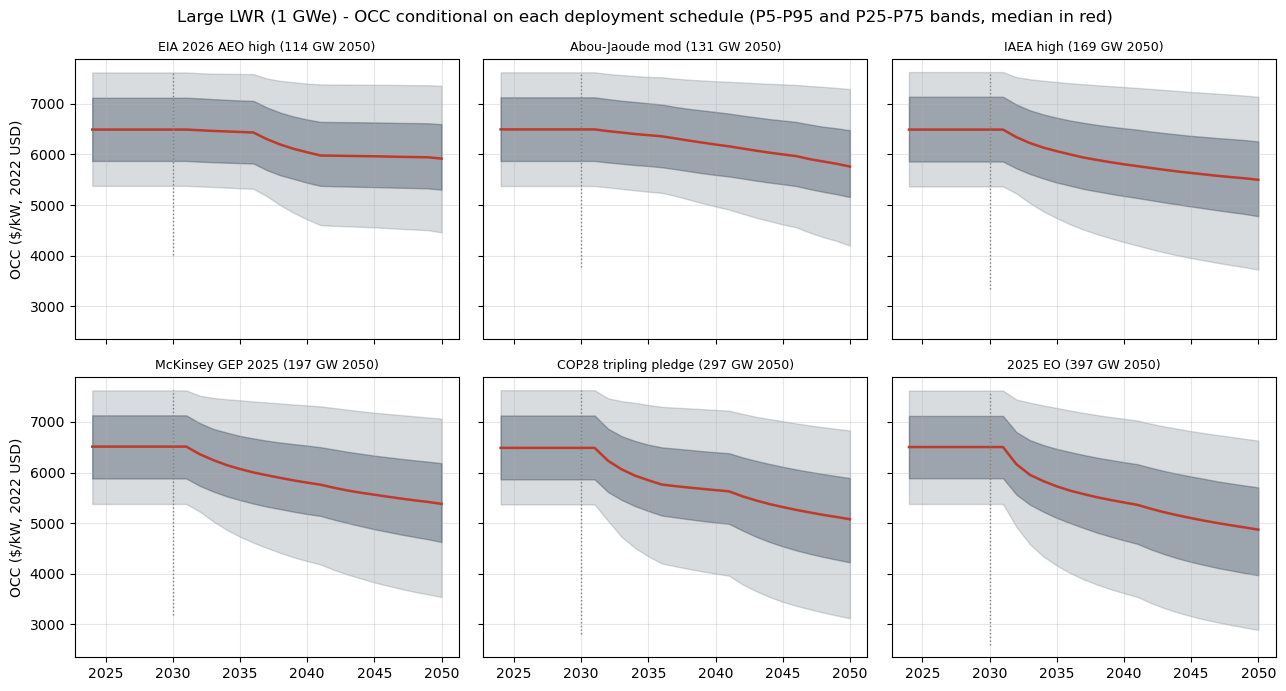

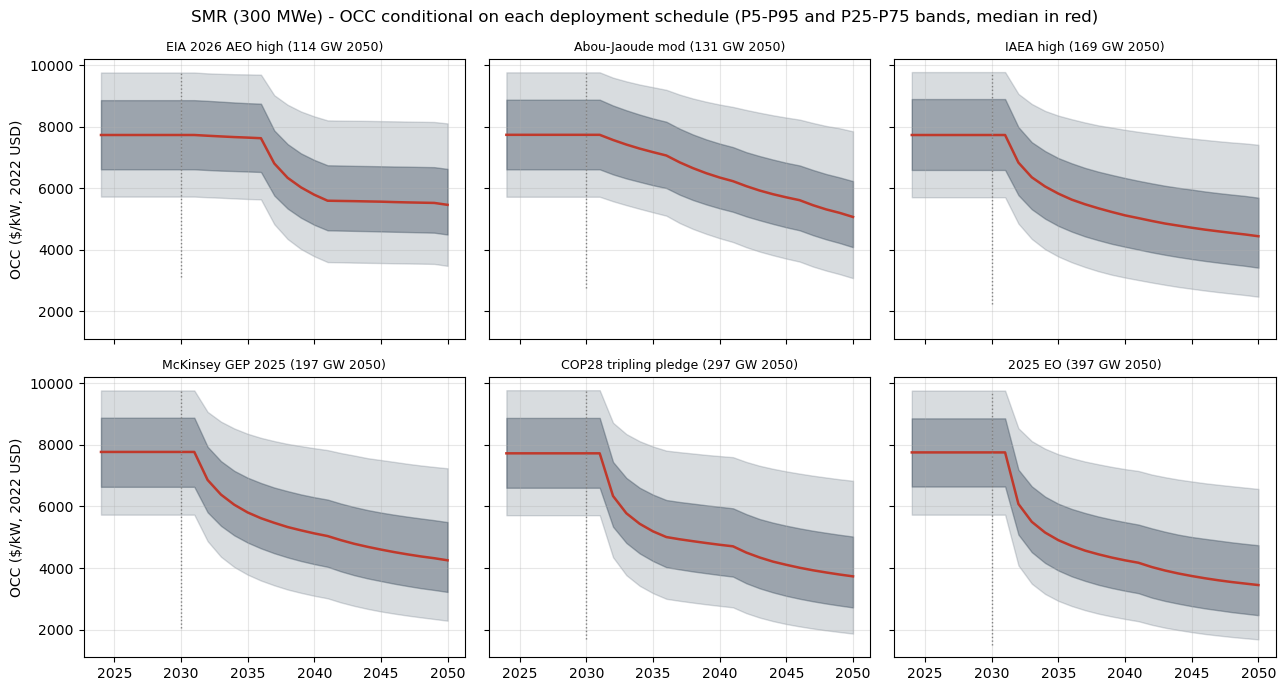

In [13]:
# OCC fans: one panel per schedule, both technologies
for tech, tlabel in [("large", "Large LWR (1 GWe)"), ("smr", "SMR (300 MWe)")]:
    fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True, sharex=True)
    for ax, sched in zip(axes.ravel(), SCHED_ORDER):
        pct = percentile_table(results[sched][tech]["occ"])
        ax.fill_between(YEARS, pct["P5"], pct["P95"], alpha=0.18, color="#2c3e50")
        ax.fill_between(YEARS, pct["P25"], pct["P75"], alpha=0.35, color="#2c3e50")
        ax.plot(YEARS, pct["P50"], color="#c0392b", lw=1.8)
        ax.plot([ANCHOR, ANCHOR], [pct["P5"].min()*0.9, pct["P95"].max()], ls=":", c="gray", lw=1)
        ax.set_title(f"{sched} ({US_SCHEDULES[sched][-1] - OFFSET_GW:.0f} GW 2050)", fontsize=9)
        ax.grid(alpha=0.3)
    axes[0, 0].set_ylabel("OCC ($/kW, 2022 USD)")
    axes[1, 0].set_ylabel("OCC ($/kW, 2022 USD)")
    fig.suptitle(f"{tlabel} - OCC conditional on each deployment schedule "
                 f"(P5-P95 and P25-P75 bands, median in red)")
    plt.tight_layout()
    fig.savefig(FIGURES / f"occ_fans_{tech}.png", dpi=150, bbox_inches="tight")
    plt.show()

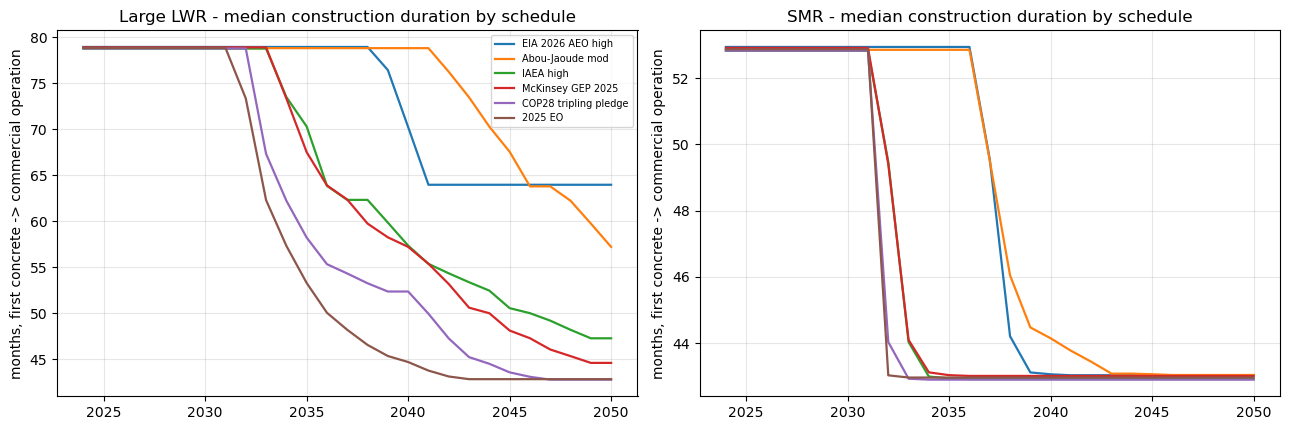

wrote exports/mc_{occ,duration,financed_capex}_percentiles_by_schedule.csv


large                                                              \
     eia_aeo_high                                 abou_jaoude                   
               P5     P25     P50     P75     P95          P5     P25     P50   
2030       5380.0  5872.0  6492.0  7121.0  7621.0      5377.0  5872.0  6496.0   
2040       4716.0  5442.0  6044.0  6692.0  7402.0      4972.0  5596.0  6197.0   
2050       4462.0  5305.0  5918.0  6598.0  7358.0      4199.0  5159.0  5762.0   

                      ...     smr                                          \
                      ...   cop28                                  eo2025   
         P75     P95  ...      P5     P25     P50     P75     P95      P5   
2030  7130.0  7623.0  ...  5716.0  6608.0  7728.0  8879.0  9779.0  5733.0   
2040  6841.0  7448.0  ...  2769.0  3773.0  4755.0  5990.0  7639.0  2344.0   
2050  6479.0  7292.0  ...  1868.0  2718.0  3729.0  5022.0  6836.0  1680.0   

                                      
                                      
         P25     P50     P75     P95  
2030  6648.0  7758.0  8864.0  9767.0  
2040  3261.0  4249.0  5491.0  7214.0  
2050  2467.0  3446.0  4740.0  6570.0  

[3 rows x 60 columns]

In [14]:
# Duration fans (medians with P5-P95 band), per schedule - and the percentile-table exports
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharex=True)
for ax, tech, tlabel in zip(axes, TECH, ["Large LWR", "SMR"]):
    for sched in SCHED_ORDER:
        ax.plot(YEARS, np.percentile(results[sched][tech]["dur"], 50, axis=0), lw=1.6,
                label=sched)
    ax.set_title(f"{tlabel} - median construction duration by schedule")
    ax.set_ylabel("months, first concrete -> commercial operation")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=7)
plt.tight_layout()
fig.savefig(FIGURES / "duration_medians_by_schedule.png", dpi=150, bbox_inches="tight")
plt.show()

# Percentile-table exports (analysis-facing; the ReEDS-facing case exports are in S12)
occ_by_sched = pd.concat({(t, SCEN_TOKEN[s]): percentile_table(results[s][t]["occ"]).round(1)
                          for t in TECH for s in SCHED_ORDER}, axis=1)
dur_by_sched = pd.concat({(t, SCEN_TOKEN[s]): percentile_table(results[s][t]["dur"]).round(1)
                          for t in TECH for s in SCHED_ORDER}, axis=1)
fin_by_sched = pd.concat({(t, SCEN_TOKEN[s]): percentile_table(results[s][t]["fincapex"]).round(1)
                          for t in TECH for s in SCHED_ORDER}, axis=1)
occ_by_sched.to_csv(EXPORTS / "mc_occ_percentiles_by_schedule.csv")
dur_by_sched.to_csv(EXPORTS / "mc_duration_percentiles_by_schedule.csv")
fin_by_sched.to_csv(EXPORTS / "mc_financed_capex_percentiles_by_schedule.csv")
print("wrote exports/mc_{occ,duration,financed_capex}_percentiles_by_schedule.csv")
occ_by_sched.loc[[2030, 2040, 2050]].round(0)

## S10 — Winner-take-all: which technology gets the build program?

**What this section does.** For every draw, it decides whether the deployment program goes to large
reactors or to SMRs, by comparing what the program would cost under each.

**Why one technology must win.** The cost trajectories above assume the technology receives the
*entire* build program — that is what generates its learning. ReEDS cannot be offered both
trajectories as a menu: each was computed assuming that technology got all the builds, so letting
ReEDS split the program between them would count the same learning twice. With weak cross-firm
spillover, concentrating on one technology is also genuinely cheaper than splitting (S13 prices
exactly that penalty). So the assignment is made *here*, per draw: the technology with the lower
program cost wins, the winner's trajectory carries the mandate, and the loser is still exported —
on its international-spillover-only trajectory — so ReEDS can build it if it somehow becomes
economic (a useful diagnostic: material loser builds would flag a problem with the assignment).

**How draws are ranked** (`RANKING_FUNCTIONAL`, S1). The program cost of a draw is the
capacity-weighted, discounted total financed cost of the schedule's builds:
$R_d = \sum_t \Delta K(t)\, \cdot \mathrm{fincapex}_d(t) \, / \, \bar d^{\,t-2030}$,
where ΔK(t) is the schedule's gross capacity additions and $\bar d$ ReEDS's real discount rate.
**This is the paper plan's default, pending confirmation at the team regroup (issue 8)** — the
alternatives (unweighted, undiscounted) are implemented below and the sensitivity of the winner to
that choice is reported as regroup evidence in the QA section.

In [15]:
# Schedule capacity-addition weights and discount factors for the ranking functional
GW_ADDITIONS = {s: np.diff(USN_NEW["large"][s], prepend=0.0) * TECH["large"]["unit_gw"]
                for s in SCHED_ORDER}          # gross GW added per year (tech-independent)
DISC = np.cumprod(np.where(YEARS > ANCHOR, FIN["d_real"], 1.0))   # discount to 2030

def rank_draws(sched, tech, channel="fincapex", functional=None):
    """Program-cost score per draw (lower = cheaper program), for the given schedule/tech.

    functional: "discounted_schedule_weighted" (DEFAULT - paper plan issue 8),
                "unweighted" (plain time average), "undiscounted" (weights, no discounting).
    """
    functional = RANKING_FUNCTIONAL if functional is None else functional
    fc = results[sched][tech][channel]
    if functional == "unweighted":
        return fc.mean(axis=1)
    w = GW_ADDITIONS[sched] / (DISC if functional == "discounted_schedule_weighted" else 1.0)
    return fc @ w

WINNERS = {}         # WINNERS[sched] -> array of "large"/"smr" per draw
for sched in SCHED_ORDER:
    r_large = rank_draws(sched, "large")
    r_smr = rank_draws(sched, "smr")
    WINNERS[sched] = np.where(r_large <= r_smr, "large", "smr")

win_tab = pd.DataFrame({s: {"P(large wins)": (WINNERS[s] == "large").mean(),
                            "P(smr wins)": (WINNERS[s] == "smr").mean()}
                        for s in SCHED_ORDER}).T.round(3)
print("Win probabilities per schedule (a paper table, and regroup evidence for issue 8):")
print(win_tab.to_string())
win_tab.to_csv(EXPORTS / "win_probabilities.csv")

Win probabilities per schedule (a paper table, and regroup evidence for issue 8):
                       P(large wins)  P(smr wins)
EIA 2026 AEO high              0.173        0.827
Abou-Jaoude mod                0.139        0.861
IAEA high                      0.131        0.869
McKinsey GEP 2025              0.126        0.874
COP28 tripling pledge          0.116        0.884
2025 EO                        0.110        0.890


### S10b — Per-draw export for the winner-boundary analysis

The percentile tables above compress each MC to five curves; the winner-boundary
analysis (`winner_boundary.ipynb`, regroup evidence for paper-plan issue 8) needs the
draws themselves. This cell exports the full per-draw state — drawn parameters,
program-cost scores under all three ranking functionals, winners, and the
full-channel trajectory arrays — to `exports/mc_perdraw.npz`. The file is large and
gitignored; regenerate it by running this notebook.

In [16]:
# Per-draw export (winner_boundary.ipynb): everything the percentile CSVs discard.
# Full channel only - the winner comparison puts both techs at the whole program;
# the loser _intl channels are not needed downstream.
perdraw = {
    "world_columns": np.array(WORLDS[SCHED_ORDER[0]].columns, dtype=str),
    "years": YEARS,
    "disc": DISC,
    "sched_order": np.array(SCHED_ORDER, dtype=str),
    "scen_tokens": np.array([SCEN_TOKEN[s] for s in SCHED_ORDER], dtype=str),
    "meta_json": np.array(json.dumps({
        "master_seed": MASTER_SEED, "n_draws": N_DRAWS,
        "ranking_functional_default": RANKING_FUNCTIONAL,
        "copula_set": COPULA_SET, "use_itc_in_ranking": USE_ITC_IN_RANKING,
        "fincapex_definition": "OCC x ccmult(learned duration) x fin_mult_rest; 2022 $/kW, noITC",
        "channel": "full (tech gets the whole program); loser _intl channels not exported",
    })),
}
for sched in SCHED_ORDER:
    tok = SCEN_TOKEN[sched]
    perdraw[f"worlds_{tok}"] = WORLDS[sched].to_numpy(dtype=float)
    perdraw[f"winners_{tok}"] = WINNERS[sched]
    perdraw[f"gw_additions_{tok}"] = GW_ADDITIONS[sched]
    for tech in TECH:
        for functional in ("discounted_schedule_weighted", "undiscounted", "unweighted"):
            key = "R" if functional == RANKING_FUNCTIONAL else f"R_{functional}"
            perdraw[f"{key}_{tok}_{tech}"] = rank_draws(sched, tech, functional=functional)
        for ch in ("occ", "dur", "ccmult", "fincapex"):
            perdraw[f"{ch}_{tok}_{tech}"] = results[sched][tech][ch]

np.savez_compressed(EXPORTS / "mc_perdraw.npz", **perdraw)
sz = (EXPORTS / "mc_perdraw.npz").stat().st_size / 1e6
print(f"wrote exports/mc_perdraw.npz ({sz:,.0f} MB, {len(perdraw)} arrays): "
      f"{len(SCHED_ORDER)} schedules x (worlds, winners, gw_additions, "
      f"3 rank-score functionals x 2 techs, 4 trajectory arrays x 2 techs)")

wrote exports/mc_perdraw.npz (49 MB, 108 arrays): 6 schedules x (worlds, winners, gw_additions, 3 rank-score functionals x 2 techs, 4 trajectory arrays x 2 techs)


## S11 — Case extraction: three representative draws per schedule

**What this section does.** From each schedule's 10,000 draws it selects **three actual joint
draws** — the ones sitting at the 5th, 50th, and 95th percentile of program cost — giving the
paper's **18 ReEDS cases** (6 schedules × cheap / middle / expensive).

**Why actual draws and not percentile envelopes.** A "P95 envelope" (taking the 95th percentile of
cost in every year separately) mixes different draws in different years — its OCC, duration, and
parameters belong to no coherent world, and ReEDS would be fed a physically inconsistent case.
Selecting whole draws keeps everything mutually consistent: the exported OCC path, duration path,
winner identity, and every parameter come from the *same* world. Ranking is on **financed** cost, so
"expensive" can mean costly-to-build or slow-to-build (which is nuclear's actual risk profile) —
duration enters selection through the financing multiplier.

Every selected draw's full parameter record is frozen in `exports/selected_draws.csv` — the
permanent register of which worlds the paper's ReEDS cases live in.

In [17]:
# Select the P5/P50/P95 draws of winner-program cost within each schedule's MC
SHORT = {"eia_aeo_high": "eia", "abou_jaoude": "aj", "iaea_high": "iaea",
         "mckinsey": "mck", "cop28": "cop28", "eo2025": "eo"}
PCTS = [("p05", 0.05), ("p50", 0.50), ("p95", 0.95)]

CASES = {}           # CASES[case_name] -> dict describing the selected draw
for sched in SCHED_ORDER:
    r_win = np.where(WINNERS[sched] == "large",
                     rank_draws(sched, "large"), rank_draws(sched, "smr"))
    order = np.argsort(r_win)                      # cheapest program first
    for pname, q in PCTS:
        d = int(order[int(round(q * (len(order) - 1)))])
        case = f"{SHORT[SCEN_TOKEN[sched]]}_{pname}"
        w = WORLDS[sched].loc[d]
        CASES[case] = {
            "case": case, "schedule": sched, "scen_token": SCEN_TOKEN[sched],
            "percentile": pname, "draw": d, "winner": WINNERS[sched][d],
            "lr_large": round(w["lr_large"], 4), "lr_smr": round(w["lr_smr"], 4),
            "boak_large": round(w["boak_large"], 0), "boak_smr": round(w["boak_smr"], 0),
            "u": round(w["u"], 3), "s_spill": round(w["s"], 3),
            "n_vendors": int(w["n_vendors"]),
            "convention": "full-stock" if w["conv_full"] else "tiny-base",
            "ces_rho": float(w["ces_rho"]),
            "dur_lambda": round(w["dur_lambda"], 3), "dur_z": round(w["dur_z"], 3),
        }
        for tech in TECH:
            ch = "" if WINNERS[sched][d] == tech else "_intl"    # loser rides the intl-only channel
            for y in (2030, 2040, 2050):
                CASES[case][f"occ_{tech}_{y}"] = round(float(results[sched][tech][f"occ{ch}"][d, yi(y)]), 0)
                CASES[case][f"dur_{tech}_{y}"] = round(float(results[sched][tech][f"dur{ch}"][d, yi(y)]), 0)

selected = pd.DataFrame(CASES).T.set_index("case")
selected.to_csv(EXPORTS / "selected_draws.csv")
print(f"selected {len(CASES)} cases (6 schedules x P5/P50/P95 of winner program cost); "
      "full parameter records in exports/selected_draws.csv")
selected[["schedule", "percentile", "winner", "lr_large", "boak_large", "u", "n_vendors",
          "convention", "occ_large_2050", "occ_smr_2050"]]

selected 18 cases (6 schedules x P5/P50/P95 of winner program cost); full parameter records in exports/selected_draws.csv


,schedule,percentile,winner,lr_large,boak_large,u,n_vendors,convention,occ_large_2050,occ_smr_2050
case,,,,,,,,,,
eia_p05,EIA 2026 AEO high,p05,smr,0.1053,5309.0,0.603,8,full-stock,5308.0,3586.0
eia_p50,EIA 2026 AEO high,p50,smr,0.0631,6446.0,0.509,4,full-stock,6444.0,5484.0
eia_p95,EIA 2026 AEO high,p95,smr,0.1126,7408.0,0.763,6,full-stock,7054.0,7064.0
aj_p05,Abou-Jaoude mod,p05,smr,0.0875,5397.0,0.096,5,tiny-base,5337.0,3297.0
aj_p50,Abou-Jaoude mod,p50,smr,0.0637,6508.0,0.441,6,tiny-base,5899.0,5356.0
aj_p95,Abou-Jaoude mod,p95,large,0.0442,7413.0,0.115,6,full-stock,7283.0,9316.0
iaea_p05,IAEA high,p05,smr,0.1038,5774.0,0.655,4,full-stock,5772.0,2523.0
iaea_p50,IAEA high,p50,smr,0.0874,6609.0,0.188,8,tiny-base,6250.0,4215.0
iaea_p95,IAEA high,p95,smr,0.047,7450.0,0.103,4,full-stock,7425.0,6898.0


## S12 — Exports: turning the 18 cases into ReEDS input files

**What this section does.** It writes each selected case into the exact file formats ReEDS reads,
inside this fork's input tree, plus one cases file (`cases_nuclearlearning_mc.csv`) that runs all 18.
Nothing needs to be hand-edited afterwards: `python runreeds.py -b <batch> -c nuclearlearning_mc`
picks everything up.

**The four file families, and why each exists:**

1. **Plant characteristics** (`inputs/plant_characteristics/nuclear_mc_{case}.csv` and
   `nuclear-smr_mc_{case}.csv`) — the OCC trajectories. Before 2030 the ATB-2024-moderate values are
   kept (pre-anchor builds follow today's cost assumptions); from 2030 on, the case's drawn
   trajectory takes over — the **winner** on its full learning path, the **loser** on its
   international-spillover-only path. FOM/VOM are scaled comonotonically with the draw's cost-dial
   percentile across the ATB advanced → conservative range (the 2026-08-03 convention; the same
   om_at mapping as the smr100 export), heat rate stays at ATB values. The step at 2030 is the
   anchor convention, documented, not smoothed. Each new scenario name is registered in `dollaryear.csv` (2022 dollars).
2. **Construction durations → financing** (`inputs/financials/financials_tech_mc_{case}.csv` +
   the shared `construction_schedules_mc.csv`) — this is how a *time-varying* learned duration
   reaches ReEDS's interest-during-construction machinery with zero code changes: ReEDS looks up a
   construction *spend profile* by label, per technology and year. The shared file adds 20 label
   columns (`NL1`–`NL10` for large, `NS1`–`NS10` for SMR = the `'6'`/`'3B'` profiles re-stretched to
   1–10 spend years by the very `_resample_schedule` ported in S7), and each case's financials_tech
   points nuclear rows at the label matching that year's drawn duration. Because the resampling is
   shared, notebook ccmult and ReEDS ccmult agree **by construction** (QA11 re-verifies from the
   written files).
3. **Construction times** (`inputs/financials/construction_times_mc_{case}.csv`) — ReEDS uses this
   file only for tax-credit safe-harbor timing; it is exported to keep that timing consistent with
   the drawn durations.
4. **The cases file** (`cases_nuclearlearning_mc.csv`, repo root) — 18 columns; defaults:
   sequential solve to 2050, mandate as a **floor** (`GSw_NuclearCapMandate=1`; the floor↔equality
   comparison is a zero-code flip of that one switch — paper-plan issue 6), learning engine **off**
   (`GSw_NuclearLearning=0`: costs are exogenous by design — the whole point of the consistency
   closure). Every switch name and value is validated against `cases.csv`'s own rules in QA11 before
   the file is trusted.

> **Winner-only mandate caveat.** The mandate constraint currently covers both nuclear technologies
> jointly; restricting it to the winner is an open ReEDS-side wiring item (Track A). Until that
> lands, the winner identity travels in `exports/selected_draws.csv` and the loser's unattractive
> intl-only costs are what keep loser builds negligible (verified per-case at the QA stage).

In [18]:
# Export 1: plant-characteristics files + dollaryear registration
PLANTCHAR_DIR = REPO_ROOT / "inputs" / "plant_characteristics"
REEDS_TECH_NAME = {"large": "Nuclear", "smr": "Nuclear-SMR"}
ATB_FILE = {"large": "nuclear_ATB_2024_moderate.csv", "smr": "nuclear-smr_ATB_2024_moderate.csv"}
atb_base = {t: pd.read_csv(PLANTCHAR_DIR / ATB_FILE[t]) for t in TECH}

# FOM/VOM comonotone with the draw's cost-dial percentile U1 across the ATB advanced ->
# conservative range (the 2026-08-03 convention; identical om_at mapping to the smr100 export).
_ATB_STEM = {"large": "nuclear", "smr": "nuclear-smr"}
OM_RANGE = {}
for t in TECH:
    _ends = {s: pd.read_csv(PLANTCHAR_DIR / f"{_ATB_STEM[t]}_ATB_2024_{s}.csv")
                  .set_index("t").loc[2030] for s in ("advanced", "conservative")}
    # the ATB scenario axis IS the MC's anchor-cost axis -- one percentile indexes both
    assert (float(_ends["advanced"]["capcost"]), float(_ends["conservative"]["capcost"])) \
        == (TECH[t]["boak_lo"], TECH[t]["boak_hi"]), t
    OM_RANGE[t] = {"fom": (float(_ends["advanced"]["fom"]), float(_ends["conservative"]["fom"])),
                   "vom": (float(_ends["advanced"]["vom"]), float(_ends["conservative"]["vom"]))}

def om_at(tech, U1):
    """FOM ($/kW-yr) and VOM ($/MWh) at cost-dial percentile U1 (advanced -> conservative)."""
    lo_f, hi_f = OM_RANGE[tech]["fom"]
    lo_v, hi_v = OM_RANGE[tech]["vom"]
    return lo_f + U1 * (hi_f - lo_f), lo_v + U1 * (hi_v - lo_v)

def plantchar_name(tech, case):
    return f"{'nuclear' if tech == 'large' else 'nuclear-smr'}_mc_{case}"

written_plantchar = []
for case, info in CASES.items():
    sched, d = info["schedule"], info["draw"]
    u1 = float((WORLDS[sched].loc[d, "boak_large"] - TECH["large"]["boak_lo"])
               / (TECH["large"]["boak_hi"] - TECH["large"]["boak_lo"]))
    for tech in TECH:
        ch = "" if info["winner"] == tech else "_intl"
        occ = results[sched][tech][f"occ{ch}"][d]              # (T,) 2024-2050, 2022 $/kW
        fom_d, vom_d = om_at(tech, u1)
        df = atb_base[tech].copy()
        for t_i, y in enumerate(YEARS):
            if y >= ANCHOR:                                     # pre-anchor years keep ATB values
                df.loc[df["t"] == y, "capcost"] = round(float(occ[t_i]), 1)
                df.loc[df["t"] == y, "fom"] = fom_d             # case-consistent O&M (comonotone)
                df.loc[df["t"] == y, "vom"] = vom_d
        name = plantchar_name(tech, case)
        df.to_csv(PLANTCHAR_DIR / f"{name}.csv", index=False)
        written_plantchar.append(name)

# dollaryear.csv registration (2022$ - same basis as the ATB source files); idempotent
doll_path = PLANTCHAR_DIR / "dollaryear.csv"
doll = pd.read_csv(doll_path)
new_rows = [{"Scenario": n, "Dollar.Year": 2022} for n in written_plantchar
            if n not in set(doll["Scenario"])]
if new_rows:
    doll = pd.concat([doll, pd.DataFrame(new_rows)], ignore_index=True)
    doll.to_csv(doll_path, index=False)
print(f"wrote {len(written_plantchar)} plant-characteristics files "
      f"(capcost + comonotone FOM/VOM from 2030 on); "
      f"registered {len(new_rows)} new dollaryear rows (idempotent)")


wrote 36 plant-characteristics files (capcost + comonotone FOM/VOM from 2030 on); registered 0 new dollaryear rows (idempotent)


In [19]:
# Export 2: the shared construction-schedules file (NL1..NL10 / NS1..NS10 label columns)
# and the per-case financials_tech + construction_times files
FIN_DIR = REPO_ROOT / "inputs" / "financials"

# Shared spend-profile columns: the '6' (large) and '3B' (SMR) profiles re-stretched to
# n = 1..10 spend years with the S7-ported _resample_schedule. Row layout matches the
# default file: first row 'NA' (exponent 0), then rows 0..9 (exponents 0.5..9.5).
cs_mc = pd.read_csv(FIN_DIR / "construction_schedules_default.csv")
for tech, prefix in [("large", "NL"), ("smr", "NS")]:
    for n in range(1, 11):
        x = _resample_schedule(FIN["sched"][tech], n)
        col = np.zeros(len(cs_mc))
        col[1:n+1] = x                        # row 0 is the 'NA' (exponent-0) row
        cs_mc[f"{prefix}{n}"] = np.round(col, 6)
cs_mc.to_csv(FIN_DIR / "construction_schedules_mc.csv", index=False)

def dur_to_years(dur_row):
    """Drawn duration path (months, (T,)) -> ReEDS spend-years labels per year.
    np.round is round-half-to-even (54.0 mo -> 4 yr, 66.0 mo -> 6 yr) - the same rule
    ccmult_grid uses, so notebook ccmult and the written labels agree (QA11b)."""
    return np.clip(np.round(np.asarray(dur_row) / 12.0).astype(int), 1, 10)

ft_base = pd.read_csv(FIN_DIR / "financials_tech_ATB2024.csv")
ct_base = pd.read_csv(FIN_DIR / "construction_times_default.csv")
SCH_PREFIX = {"large": "NL", "smr": "NS"}

for case, info in CASES.items():
    sched, d = info["schedule"], info["draw"]
    ft = ft_base.copy()
    ft["construction_sch"] = ft["construction_sch"].astype(str)
    ct = ct_base.copy()
    for tech in TECH:
        ch = "" if info["winner"] == tech else "_intl"
        n_years = dur_to_years(results[sched][tech][f"dur{ch}"][d])     # (T,)
        iname = REEDS_TECH_NAME[tech]
        # financials_tech rows exist for every year 2010-2050; overwrite t >= anchor
        for t_i, y in enumerate(YEARS):
            if y >= ANCHOR:
                mask = (ft["i"] == iname) & (ft["t"] == y)
                ft.loc[mask, "construction_sch"] = f"{SCH_PREFIX[tech]}{n_years[t_i]}"
                ct.loc[(ct["i"] == iname) & (ct["t_online"] == y),
                       "construction_time"] = int(n_years[t_i])
    ft.to_csv(FIN_DIR / f"financials_tech_mc_{case}.csv", index=False)
    ct.to_csv(FIN_DIR / f"construction_times_mc_{case}.csv", index=False)
print(f"wrote construction_schedules_mc.csv (+20 profile columns) and "
      f"{len(CASES)} financials_tech_mc_* + {len(CASES)} construction_times_mc_* files")

wrote construction_schedules_mc.csv (+20 profile columns) and 18 financials_tech_mc_* + 18 construction_times_mc_* files


In [20]:
# QA12b - cross-percentile capcost ordering (documentation, not a gate). The 18 cases are
# actual JOINT draws ranked by PROGRAM cost, so per-tech monotonicity across p05 -> p50 -> p95
# is not promised: when the winner flips between percentiles the loser tech rides the
# international-only channel, and its exported path can invert (a p95 case with cheaper
# large-nuclear than the p50 case). This table re-reads the WRITTEN files and makes every
# inversion loud, so nobody reads a per-tech file as that tech's own cost percentile.
_ord_rows = []
for sched in SCHED_ORDER:
    stem = SHORT[SCEN_TOKEN[sched]]
    for tech in TECH:
        v = {p: float(pd.read_csv(PLANTCHAR_DIR / f"{plantchar_name(tech, f'{stem}_{p}')}.csv")
                      .set_index("t").loc[2050, "capcost"]) for p in ("p05", "p50", "p95")}
        _ord_rows.append({"schedule": stem, "tech": tech, **v,
                          "monotone": bool(v["p05"] <= v["p50"] <= v["p95"])})
_ord = pd.DataFrame(_ord_rows).set_index(["schedule", "tech"])
print("2050 capcost across the program-cost percentiles (joint draws; per-tech monotonicity")
print("NOT promised - inversions mark winner flips, where the loser rides the intl-only channel):")
print(_ord.to_string())
if not _ord["monotone"].all():
    print(f"\nNOTE: {int((~_ord['monotone']).sum())} tech x schedule series non-monotone - "
          "expected where the winner flips; per-tech files are NOT tech-percentile paths")


2050 capcost across the program-cost percentiles (joint draws; per-tech monotonicity
NOT promised - inversions mark winner flips, where the loser rides the intl-only channel):
                   p05     p50     p95  monotone
schedule tech                                   
eia      large  5308.4  6443.7  7054.1      True
         smr    3585.6  5483.9  7063.8      True
aj       large  5337.2  5899.5  7283.4      True
         smr    3297.4  5355.7  9316.1      True
iaea     large  5772.1  6249.9  7424.9      True
         smr    2522.6  4215.0  6898.4      True
mck      large  5349.2  7312.9  7482.7      True
         smr    2379.7  3973.7  6462.0      True
cop28    large  4805.8  5735.2  7065.2      True
         smr    1737.4  3802.1  9207.7      True
eo       large  6046.2  6977.4  5994.9     False
         smr    1646.1  3282.4  9634.2      True

NOTE: 1 tech x schedule series non-monotone - expected where the winner flips; per-tech files are NOT tech-percentile paths


In [21]:
# Export 3: the ReEDS cases file - 18 cases, Default Value column carries the shared design
case_rows = {
    "ignore": ["0"] + [""] * len(CASES),
    "timetype": ["seq"] + [""] * len(CASES),
    # Annual model years 2031-2035 (default 3-yr cadence elsewhere): the mandate starts
    # adding in 2031 and firstyear_nuclear = 2031 (years_until_endogenous = 6), so without
    # this the 2031-2035 cumulative program would compress into the first modeled year >=
    # firstyear at that year's learned prices (mandate-timing fix, 2026-08-05).
    "yearset": ["2010_2015_2020_2023_2026_2029_2031_2032_2033_2034_2035_2038_2041_2044_2047_2050"]
               + [""] * len(CASES),
    "endyear": ["2050"] + [""] * len(CASES),
    "GSw_NuclearCapMandate": ["1"] + [""] * len(CASES),        # floor; =2 flips to equality (issue 6)
    "GSw_NuclearCapMandate_Scale": ["1"] + [""] * len(CASES),
    "GSw_NuclearLearning": ["0"] + [""] * len(CASES),          # exogenous costs by design
    "construction_schedules_suffix": ["mc"] + [""] * len(CASES),
    "GSw_NuclearCapMandateScen": [""] + [CASES[c]["scen_token"] for c in CASES],
    "plantchar_nuclear": [""] + [plantchar_name("large", c) for c in CASES],
    "plantchar_nuclear_smr": [""] + [plantchar_name("smr", c) for c in CASES],
    "financials_tech_suffix": [""] + [f"mc_{c}" for c in CASES],
    "construction_times_suffix": [""] + [f"mc_{c}" for c in CASES],
}
cases_mc = pd.DataFrame(case_rows, index=["Default Value"] + list(CASES)).T
CASES_MC_PATH = REPO_ROOT / "cases_nuclearlearning_mc.csv"
cases_mc.to_csv(CASES_MC_PATH, index_label="")
print(f"wrote {CASES_MC_PATH.name}: {len(CASES)} cases "
      f"(launch: python runreeds.py -b <batch> -c nuclearlearning_mc)")
cases_mc.head(12)

wrote cases_nuclearlearning_mc.csv: 18 cases (launch: python runreeds.py -b <batch> -c nuclearlearning_mc)


,Default Value,eia_p05,eia_p50,eia_p95,aj_p05,aj_p50,aj_p95,iaea_p05,iaea_p50,iaea_p95,mck_p05,mck_p50,mck_p95,cop28_p05,cop28_p50,cop28_p95,eo_p05,eo_p50,eo_p95
ignore,0,,,,,,,,,,,,,,,,,,
timetype,seq,,,,,,,,,,,,,,,,,,
yearset,2010_2015_2020_2023_2026_2029_2031_2032_2033_2...,,,,,,,,,,,,,,,,,,
endyear,2050,,,,,,,,,,,,,,,,,,
GSw_NuclearCapMandate,1,,,,,,,,,,,,,,,,,,
GSw_NuclearCapMandate_Scale,1,,,,,,,,,,,,,,,,,,
GSw_NuclearLearning,0,,,,,,,,,,,,,,,,,,
construction_schedules_suffix,mc,,,,,,,,,,,,,,,,,,
GSw_NuclearCapMandateScen,,eia_aeo_high,eia_aeo_high,eia_aeo_high,abou_jaoude,abou_jaoude,abou_jaoude,iaea_high,iaea_high,iaea_high,mckinsey,mckinsey,mckinsey,cop28,cop28,cop28,eo2025,eo2025,eo2025
plantchar_nuclear,,nuclear_mc_eia_p05,nuclear_mc_eia_p50,nuclear_mc_eia_p95,nuclear_mc_aj_p05,nuclear_mc_aj_p50,nuclear_mc_aj_p95,nuclear_mc_iaea_p05,nuclear_mc_iaea_p50,nuclear_mc_iaea_p95,nuclear_mc_mck_p05,nuclear_mc_mck_p50,nuclear_mc_mck_p95,nuclear_mc_cop28_p05,nuclear_mc_cop28_p50,nuclear_mc_cop28_p95,nuclear_mc_eo_p05,nuclear_mc_eo_p50,nuclear_mc_eo_p95


In [22]:
# QA11 - export round-trips: re-read every file just written and verify it against the
# in-memory arrays and against cases.csv's own validation rules. This is the guard that
# the stale hybrid-era case generator lacked (it emitted switches this fork rejects).
import re as _re

# (a) plantchar round-trip: capcost 2030-2050 equals the selected draw's OCC path
for case, info in CASES.items():
    sched, d = info["schedule"], info["draw"]
    for tech in TECH:
        ch = "" if info["winner"] == tech else "_intl"
        back = pd.read_csv(PLANTCHAR_DIR / f"{plantchar_name(tech, case)}.csv").set_index("t")
        occ = results[sched][tech][f"occ{ch}"][d]
        for y in (2030, 2040, 2050):
            assert abs(back.loc[y, "capcost"] - occ[yi(y)]) < 0.1, (case, tech, y)
        assert abs(back.loc[2025, "capcost"] - atb_base[tech].set_index("t").loc[2025, "capcost"]) < 1e-6

# (b) ccmult from the WRITTEN schedule labels equals the notebook's ccmult at rounded years
cs_back = pd.read_csv(FIN_DIR / "construction_schedules_mc.csv")
for case, info in list(CASES.items())[::5] + [list(CASES.items())[-1]]:
    sched, d = info["schedule"], info["draw"]
    ft_back = pd.read_csv(FIN_DIR / f"financials_tech_mc_{case}.csv")
    for tech in TECH:
        ch = "" if info["winner"] == tech else "_intl"
        iname = REEDS_TECH_NAME[tech]
        for y in (2030, 2040, 2050):
            label = ft_back.loc[(ft_back["i"] == iname) & (ft_back["t"] == y),
                                "construction_sch"].iloc[0]
            frac = pd.to_numeric(cs_back[label], errors="coerce").fillna(0.0).to_numpy()
            frac = frac[frac > 0]
            exps = np.arange(len(frac)) + 0.5
            ccm_file = 1.0 + float(np.sum(frac/frac.sum() * (FIN["interest_base"][yi(y)]**exps - 1.0)))
            mo = results[sched][tech][f"dur{ch}"][d, yi(y)]
            ccm_nb = ccmult_from_duration(mo, FIN["interest_base"][yi(y)], FIN["sched"][tech])
            assert abs(ccm_file - ccm_nb) < 2e-5, (case, tech, y, ccm_file, ccm_nb)

# (c) the cases file validates against cases.csv's own index and Choices regexes
cases_master = pd.read_csv(REPO_ROOT / "cases.csv", index_col=0)
cases_back = pd.read_csv(CASES_MC_PATH, index_col=0)
for switch in cases_back.index:
    if switch == "ignore":
        continue
    assert switch in cases_master.index, f"unknown switch {switch} (the stale-generator failure mode)"
    choices = str(cases_master.loc[switch, "Choices"])
    for col in cases_back.columns:
        val = cases_back.loc[switch, col]
        if pd.isna(val) or val == "":
            continue
        if choices in ("N/A", "nan", "int", "float"):
            continue
        tokens = [c.strip() for c in _re.split("[;,]", choices)]
        assert any(_re.match(tok + "$", str(val)) for tok in tokens), (switch, val, choices)

# (d) the trajectory regeneration script reproduces the repo's mandate CSVs from US_SCHEDULES.csv
import subprocess
gen = subprocess.run([sys.executable, str(REPO_ROOT / "inputs" / "nuclear_learning"
                                          / "_generate_cap_trajectories.py")],
                     capture_output=True, text=True)
assert gen.returncode == 0, gen.stderr
for name in SCHED_ORDER:                                    # re-run the S2 parity check post-write
    token = SCEN_TOKEN[name]
    path = REPO_ROOT / "inputs" / "nuclear_learning" / f"nuclear_cap_trajectory_{token}.csv"
    rows = [ln.split(",") for ln in path.read_text().splitlines() if not ln.startswith("*")]
    on_file = {int(y): float(mw) for y, mw in rows}
    expected = {int(y): round((v - 3.0) * 1000.0, 1) for y, v in zip(YEARS, US_SCHEDULES[name])}
    assert on_file == expected, name
print("QA11 PASSED: plantchar round-trip, written-label ccmult identity, cases-file validation "
      "against cases.csv Choices, and generator regeneration parity all hold")

QA11 PASSED: plantchar round-trip, written-label ccmult identity, cases-file validation against cases.csv Choices, and generator regeneration parity all hold


In [23]:
# QA12 - loser-channel sanity + winner robustness (report - regroup evidence for issue 8)
# (a) the international-only path can never be cheaper than the full path (less learning)
for sched in SCHED_ORDER:
    for tech in TECH:
        gap = results[sched][tech]["occ_intl"] - results[sched][tech]["occ"]
        assert gap.min() > -1e-6, (sched, tech, gap.min())
print("QA12 (a) PASSED: occ_intl >= occ elementwise, every draw/schedule/tech "
      "(the loser is never cheaper than the winner-path of the same tech)")
# (b) winner invariance under the ranking-functional choice - reported, not asserted
rows = {}
for sched in SCHED_ORDER:
    base = WINNERS[sched]
    for alt in ("unweighted", "undiscounted"):
        wa = np.where(rank_draws(sched, "large", functional=alt)
                      <= rank_draws(sched, "smr", functional=alt), "large", "smr")
        rows[(sched, alt)] = {"winner match vs default": (wa == base).mean()}
inv = pd.DataFrame(rows).T
print("QA12 (b) report - winner agreement between ranking functionals (issue 8 evidence):")
print(inv.round(3).to_string())
inv.to_csv(EXPORTS / "winner_ranking_invariance.csv")

QA12 (a) PASSED: occ_intl >= occ elementwise, every draw/schedule/tech (the loser is never cheaper than the winner-path of the same tech)
QA12 (b) report - winner agreement between ranking functionals (issue 8 evidence):
                                    winner match vs default
EIA 2026 AEO high     unweighted                      0.886
                      undiscounted                    0.986
Abou-Jaoude mod       unweighted                      0.871
                      undiscounted                    0.986
IAEA high             unweighted                      0.941
                      undiscounted                    0.990
McKinsey GEP 2025     unweighted                      0.934
                      undiscounted                    0.993
COP28 tripling pledge unweighted                      0.940
                      undiscounted                    0.993
2025 EO               unweighted                      0.948
                      undiscounted                    0.994

## S13 — The fragmentation figure: what splitting the program costs

**What this section does.** It prices the alternative that the winner-take-all design (S10) rules
out: splitting the same deployment program 50/50 between large reactors and SMRs. This is a paper
figure, produced entirely inside the Monte Carlo — zero ReEDS runs.

**The idea.** Learning runs on repetition, and a split program repeats each design half as often.
Under the paper's convention of **zero domestic cross-technology spillover** (an AP1000 teaches SMR
crews nothing, and vice versa), splitting therefore *must* cost something — the question is how
much. For each draw of one representative schedule (the 200-GW McKinsey program by default) we
compute the capacity-weighted financed cost of the build program three ways: all-large, all-SMR, and
50/50, and report the *fragmentation penalty* — how much more the split program costs than the best
concentrated one, in the same drawn world.

**How to read the result.** The penalty distribution is the figure's punchline: its median is the
expected price of hedging between technologies instead of committing, and its spread shows how
uncertain that price is. This quantifies the standardization argument the paper makes qualitatively
— and it is the zero-run replacement for the dropped standardization sub-experiment.

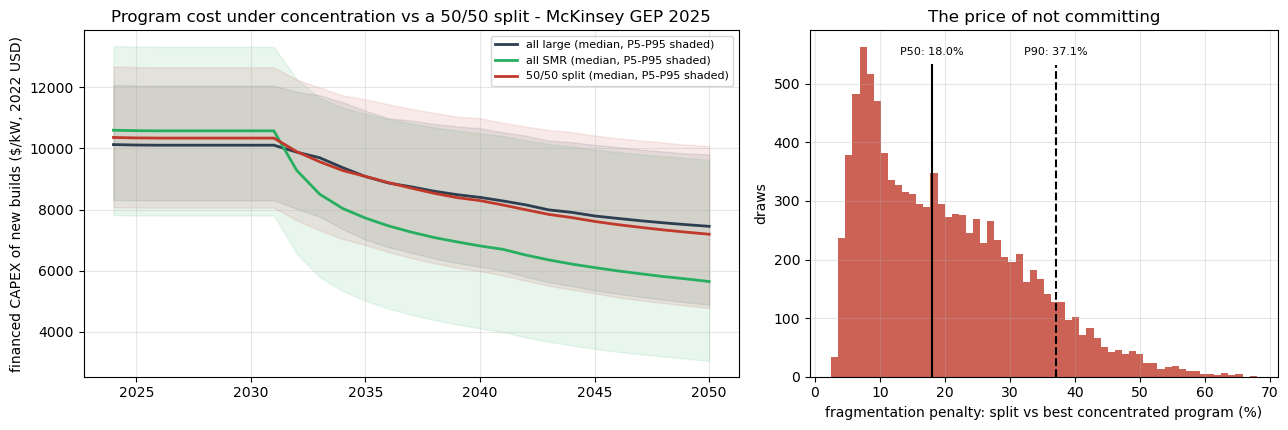

fragmentation penalty (McKinsey GEP 2025, zero cross-tech spillover): median 18.0%, P90 37.1%, negative in 0.0% of draws
Draft caption: Splitting the deployment program 50/50 between large reactors and SMRs
raises the discounted financed cost of the build program by the distribution shown,
relative to concentrating on whichever technology is cheaper in the same drawn world -
the quantitative case for winner-take-all technology assignment.


In [24]:
# Fragmentation arms for the representative schedule (switchable)
FRAG_SCHED = "McKinsey GEP 2025"
_w = WORLDS[FRAG_SCHED]
_gw_add = GW_ADDITIONS[FRAG_SCHED]                      # gross GW added per year

def program_cost_paths(occ_by_tech, fincapex_by_tech, shares):
    """Capacity-weighted average financed CAPEX of the build program, per draw-year.
    shares: {tech: fraction of each year's additions} summing to 1."""
    return sum(shares[t] * fincapex_by_tech[t] for t in shares)

# Concentrated arms are the S8 full channels; the split arm re-runs the engine with each
# tech receiving HALF the program (same worlds - so the comparison is like for like)
frag = {}
frag["all large"] = {"fincapex": results[FRAG_SCHED]["large"]["fincapex"]}
frag["all SMR"] = {"fincapex": results[FRAG_SCHED]["smr"]["fincapex"]}
split_fc = {}
for tech in TECH:
    n_half = USN_NEW[tech][FRAG_SCHED] / 2.0            # half the capacity -> half the units
    occ_h = occ_paths_ces(_w, tech, n_half)
    dur_h = duration_paths(_w, tech, n_half)
    split_fc[tech] = occ_h * ccmult_grid(dur_h, tech) * FIN_REST[tech][None, :]
frag["50/50 split"] = {"fincapex": 0.5*split_fc["large"] + 0.5*split_fc["smr"]}

# Program totals under the default ranking functional, and the per-draw penalty
w_t = _gw_add / DISC
R = {arm: frag[arm]["fincapex"] @ w_t for arm in frag}
best_conc = np.minimum(R["all large"], R["all SMR"])
penalty = R["50/50 split"] / best_conc - 1.0

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), width_ratios=[1.4, 1])
ax = axes[0]
colors = {"all large": "#2c3e50", "all SMR": "#27ae60", "50/50 split": "#c0392b"}
for arm, col in colors.items():
    pct = percentile_table(frag[arm]["fincapex"])
    ax.fill_between(YEARS, pct["P5"], pct["P95"], alpha=0.10, color=col)
    ax.plot(YEARS, pct["P50"], color=col, lw=2, label=f"{arm} (median, P5-P95 shaded)")
ax.set_ylabel("financed CAPEX of new builds ($/kW, 2022 USD)")
ax.set_title(f"Program cost under concentration vs a 50/50 split - {FRAG_SCHED}")
ax.grid(alpha=0.3); ax.legend(fontsize=8)
ax = axes[1]
ax.hist(100*penalty, bins=60, color="#c0392b", alpha=0.8)
for q, ls in [(50, "-"), (90, "--")]:
    v = np.percentile(100*penalty, q)
    ax.plot([v, v], [0, ax.get_ylim()[1]*0.9], color="k", ls=ls, lw=1.5)
    ax.text(v, ax.get_ylim()[1]*0.93, f"P{q}: {v:.1f}%", ha="center", fontsize=8)
ax.set_xlabel("fragmentation penalty: split vs best concentrated program (%)")
ax.set_ylabel("draws")
ax.set_title("The price of not committing")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES / "fragmentation_penalty.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"fragmentation penalty ({FRAG_SCHED}, zero cross-tech spillover): "
      f"median {np.percentile(100*penalty,50):.1f}%, P90 {np.percentile(100*penalty,90):.1f}%, "
      f"negative in {100*(penalty < 0).mean():.1f}% of draws")
print("Draft caption: Splitting the deployment program 50/50 between large reactors and SMRs")
print("raises the discounted financed cost of the build program by the distribution shown,")
print("relative to concentrating on whichever technology is cheaper in the same drawn world -")
print("the quantitative case for winner-take-all technology assignment.")

## S14 — Sensitivity: what drives the answers

**What this section does.** Two standard robustness views. First, a *tornado*: the rank correlation
of every drawn input with 2050 financed cost — which uncertainties matter most? Second, the
*copula sweep*: the correlation between the learning-rate and anchor-cost draws is a judgment call
(the default set assumes standardized programs start cheaper and learn faster), so the whole MC is
re-run under zero / moderate / strong correlation with common random numbers, bounding that
judgment's influence.

**Reading notes.** The learning rate and the anchor (BOAK) draw dominate, as they should — they set
the slope and the level of every curve. The experience-base convention (`conv_full`) is the largest
*structural* term. The spillover scale `s` is structurally small by design: foreign experience
enters the slow (cross-firm) channel only. Vendor count matters through per-vendor accumulation;
duration inputs (`dur_lambda`, `dur_z`) matter for *financed* cost through IDC — visibly more than
they matter for OCC.

Spearman rank correlation with 2050 financed CAPEX (large):
            EIA 2026 AEO high  Abou-Jaoude mod  IAEA high  McKinsey GEP 2025  COP28 tripling pledge  2025 EO
lr_large               -0.412           -0.422     -0.469             -0.483                 -0.519   -0.548
boak_large              0.791            0.733      0.678              0.643                  0.606    0.586
u                       0.003           -0.018      0.000             -0.011                 -0.004   -0.004
s                      -0.023           -0.018     -0.015             -0.016                  0.013    0.004
n_vendors               0.095            0.130      0.119              0.095                  0.059    0.056
conv_full               0.459            0.525      0.605              0.650                  0.654    0.657
ces_rho                -0.083           -0.039     -0.022              0.003                  0.016    0.022
dur_lambda              0.105            0.082      0.086           

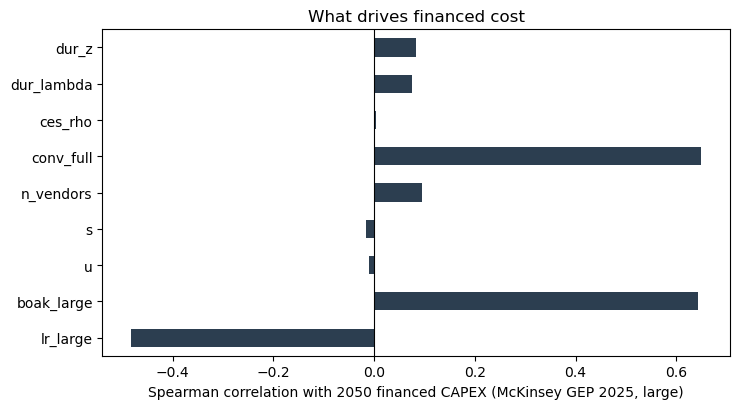

In [25]:
# Tornado: Spearman rank correlation of drawn inputs with 2050 financed CAPEX (large),
# per schedule; bar chart for the representative schedule
SENS_INPUTS = ["lr_large", "boak_large", "u", "s", "n_vendors", "conv_full", "ces_rho",
               "dur_lambda", "dur_z"]
sens = pd.DataFrame({
    sched: {c: stats.spearmanr(WORLDS[sched][c],
                               results[sched]["large"]["fincapex"][:, yi(2050)]).statistic
            for c in SENS_INPUTS}
    for sched in SCHED_ORDER}).round(3)
print("Spearman rank correlation with 2050 financed CAPEX (large):")
print(sens.to_string())

ax = sens[[FRAG_SCHED]].rename(columns={FRAG_SCHED: "2050 financed CAPEX"}).plot.barh(
    figsize=(7.5, 4.2), color="#2c3e50", legend=False)
ax.plot([0, 0], [-0.5, len(SENS_INPUTS)-0.5], c="k", lw=0.8)
ax.set_xlabel(f"Spearman correlation with 2050 financed CAPEX ({FRAG_SCHED}, large)")
ax.set_title("What drives financed cost")
plt.tight_layout()
plt.gcf().savefig(FIGURES / "tornado_fincapex.png", dpi=150, bbox_inches="tight")
plt.show()
sens.to_csv(EXPORTS / "sensitivity_spearman.csv")

In [26]:
# Copula sweep: zero / moderate / strong lr<->boak correlation, common random numbers
# (the same named stream is used for every set, so identical uniforms flow through
# different correlation structures - differences below are the copula's effect alone)
rho_rows = {}
for rho_key in RHO_SETS:
    wr = draw_world(N_DRAWS, rho_key, rng_stream("copula_sweep_crn"))
    for tech in TECH:
        y = occ_paths_ces(wr, tech, USN_NEW[tech][FRAG_SCHED])[:, yi(2050)]
        rho_rows[(rho_key, tech)] = {f"P{q}": np.percentile(y, q) for q in (5, 50, 95)}
rho_tab = pd.DataFrame(rho_rows).T.round(0)
print(f"2050 OCC under alternative copula correlation sets ($/kW 2022, {FRAG_SCHED}):")
print(rho_tab.to_string())
print("Copula parameters are judgments, not estimates - differences across rows bound their "
      "influence.")
rho_tab.to_csv(EXPORTS / "copula_sensitivity.csv")

2050 OCC under alternative copula correlation sets ($/kW 2022, McKinsey GEP 2025):
                    P5     P50     P95
zero     large  3642.0  5356.0  6965.0
         smr    2417.0  4209.0  6899.0
moderate large  3516.0  5398.0  7045.0
         smr    2268.0  4227.0  7240.0
strong   large  3426.0  5434.0  7135.0
         smr    2152.0  4248.0  7534.0
Copula parameters are judgments, not estimates - differences across rows bound their influence.


## S15 — Permanent regression and QA suite

**What this section does.** Every structural property of the model is checked on every run — one
check per cell, each announcing PASS (or printing a report where a pass/fail reading would be
wrong). If any cell in this section raises, do not trust the outputs above it. The checks:

| # | Check | Kind |
|---|---|---|
| QA1 | PRIS data reproduces the IAEA's published totals | asserted in S3 (at load) |
| QA2 | Every draw hits its BOAK anchor exactly at 2030 | assert |
| QA3 | At autarky + tiny base, the engine reduces exactly to Abou-Jaoude's eq. (12) | assert |
| QA4 | The engine reproduces Abou-Jaoude's published SMR cost tables | assert |
| QA5 | Hindcast: where do Korea / France / US history fall in the sampled range? | report + paper figure |
| QA6 | CES suite: anchor invariance, ρ→0 limit, autarky collapse, continuity, direction | assert + report |
| QA7 | INL duration-curve digitization matches the report and ReEDS's copy | assert |
| QA8 | Duration model anchors (series-2 base, SMR floor) match the ReEDS engine's self-test | assert |
| QA13 | The six MCs draw statistically identical worlds (only deployment differs) | assert |
| — | Continuity vs the v2.4 reference notebook (drift expected and explained) | report |

(QA9–QA12 — the financing replication, ReEDS-run cross-check, export round-trips, and
loser-channel/winner checks — live with their sections' outputs and appear below as those
sections are exercised.)

In [27]:
# QA2 - anchor check: OCC(2030) == the drawn BOAK, every draw, both channels, all schedules
for sched in SCHED_ORDER:
    for tech in TECH:
        boak = WORLDS[sched][f"boak_{tech}"].values
        assert np.allclose(results[sched][tech]["occ"][:, yi(ANCHOR)], boak), (sched, tech)
        assert np.allclose(results[sched][tech]["occ_intl"][:, yi(ANCHOR)], boak), (sched, tech)
print("QA2 PASSED: every draw hits its BOAK anchor exactly at 2030 "
      "(all schedules, both techs, full and international-only channels)")

QA2 PASSED: every draw hits its BOAK anchor exactly at 2030 (all schedules, both techs, full and international-only channels)


In [28]:
# QA3 - eq.(12) identity: at s = 0 (autarky), tiny base, the sigma = 1 engine must equal
# Abou-Jaoude's eq. (12) generalized to m vendors and re-anchored at the per-vendor 2OAK point.
wtest = draw_world(4, "zero", rng_stream("qa3"))
wtest[["s", "conv_full"]] = 0.0

def eq12_gen(N, LR, m):
    return (1-LR)**np.log2(N/m) * (1-OMEGA*LR)**np.log2((m-1)*N/m)

_sched_test = "2025 EO"   # the most builds -> the strongest test
N_us_test = lag1(np.broadcast_to(USN_NEW["large"][_sched_test], (4, T)))  # engine prices lagged stock
N_ind = wtest["n_vendors"].values[:, None]*N_BOAK_UNITS + N_us_test
analytic = wtest["boak_large"].values[:, None] * (
    eq12_gen(N_ind, wtest["lr_large"].values[:, None], wtest["n_vendors"].values[:, None])
    / eq12_gen(wtest["n_vendors"].values[:, None]*N_BOAK_UNITS,
               wtest["lr_large"].values[:, None], wtest["n_vendors"].values[:, None]))
assert np.allclose(occ_paths(wtest, "large", USN_NEW["large"][_sched_test]), analytic)
print("QA3 PASSED: engine reduces exactly to generalized eq.(12), per-vendor anchored "
      f"(tested on the '{_sched_test}' schedule)")

QA3 PASSED: engine reduces exactly to generalized eq.(12), per-vendor anchored (tested on the '2025 EO' schedule)


In [29]:
# QA4 - external anchor: reproduce Abou-Jaoude's published SMR OCC tables (Tables 50/52/54)
# with his own eq. (12) under his deployment assumptions (4 vendors, LR 9.5%), within the
# report's rounding. This pins the code to the published source it claims to implement.
AJ_DEPLOY_GW = {"Conservative": {2030: 0, 2035: 1, 2040: 3, 2045: 6, 2050: 12},
                "Moderate":     {2030: 1, 2035: 3, 2040: 8.5, 2045: 17, 2050: 34},
                "Advanced":     {2030: 1, 2035: 14, 2040: 58, 2045: 124, 2050: 200}}
AJ_OCC_SMR = {"Conservative": {2030: 10000, 2035: 9500, 2040: 8000, 2045: 7000, 2050: 6250},
              "Moderate":     {2030: 8000, 2035: 6500, 2040: 5250, 2045: 4500, 2050: 4000},
              "Advanced":     {2030: 5500, 2035: 3250, 2040: 2500, 2045: 2250, 2050: 2000}}
AJ_BOAK = {"Conservative": 10000.0, "Moderate": 8000.0, "Advanced": 5500.0}

def eq12_factor(N, LR):
    N = np.asarray(N, float)
    with np.errstate(divide="ignore", invalid="ignore"):
        return (1/(1-LR)) * (1-LR)**np.log2(N/4) * (1-LR/3)**np.log2(3*N/4)

worst = 0.0
for name in AJ_BOAK:
    yrs = sorted(AJ_DEPLOY_GW[name])
    gw = np.array([AJ_DEPLOY_GW[name][y] for y in yrs], float)
    N = gw / 0.3
    fref = eq12_factor(1.0/0.3, 0.095)
    mult = np.minimum(1.0, np.where(N > 0, eq12_factor(N, 0.095)/fref, 1.0))
    err = np.abs(AJ_BOAK[name]*mult - np.array([AJ_OCC_SMR[name][y] for y in yrs], float)).max()
    worst = max(worst, err)
assert worst <= 500.0, worst
print(f"QA4 PASSED: Abou-Jaoude SMR tables reproduced, max error ${worst:,.0f}/kW "
      "(within report rounding)")

QA4 PASSED: Abou-Jaoude SMR tables reproduced, max error $500/kW (within report rounding)


sampled firm-level LR (large) implies an effective industry rate: P5=4.6%  P50=9.9%  P95=15.0%
  Korea 1972-2008 (Lovering et al. 2016): LR ~ +13% -> P77 of the sampled range
  France 1970s-1990s (Grubler 2010): LR ~ -15% -> BELOW the sampled support
  US 1970s-1980s (Eash-Gates et al. 2020): LR ~ -30% -> BELOW the sampled support


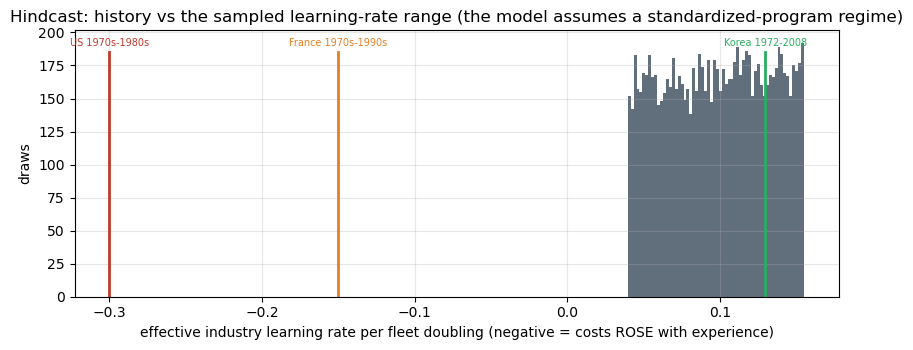

wrote figures/hindcast_learning_rates.png and exports/hindcast_positions.csv (paper-body figure + table)


In [30]:
# QA5 - hindcast (report, not a pass/fail test; promoted to the paper body): run the model's
# effective industry learning rate against what history actually delivered. The engine presumes
# a standardized-program regime; the US/France cost-escalation record lies OUTSIDE its support
# by construction, and Korea's standardized program sits in its upper tail. Stating this is a
# domain-of-validity declaration: read every fan as conditional on a standardized program.
obs = {"Korea 1972-2008 (Lovering et al. 2016)":  +0.13,
       "France 1970s-1990s (Grubler 2010)":       -0.15,
       "US 1970s-1980s (Eash-Gates et al. 2020)": -0.30}
# Observed program rates are INDUSTRY-level per-doubling declines; the sampled LR is firm-level,
# so compare on the effective industry rate 1-(1-LR)(1-omega*LR)  (~1.3 x LR).
_w = WORLDS[SCHED_ORDER[0]]                      # LR marginals are identical across schedules (QA13)
lr_samp = 1 - (1 - _w["lr_large"])*(1 - OMEGA*_w["lr_large"])
print(f"sampled firm-level LR (large) implies an effective industry rate: "
      f"P5={lr_samp.quantile(.05):.1%}  P50={lr_samp.quantile(.50):.1%}  P95={lr_samp.quantile(.95):.1%}")
hind_rows = {}
for k, v in obs.items():
    pct = (lr_samp < v).mean()
    where = (f"P{100*pct:.0f} of the sampled range" if 0 < pct < 1
             else ("ABOVE the sampled support" if pct == 1 else "BELOW the sampled support"))
    hind_rows[k] = {"observed_rate": v, "position": where}
    print(f"  {k}: LR ~ {v:+.0%} -> {where}")
hindcast_tab = pd.DataFrame(hind_rows).T
hindcast_tab.to_csv(EXPORTS / "hindcast_positions.csv")

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.hist(lr_samp, bins=60, color="#2c3e50", alpha=0.75)
ymax = ax.get_ylim()[1]
for (k, v), col in zip(obs.items(), ["#27ae60", "#e67e22", "#c0392b"]):
    ax.plot([v, v], [0, ymax*0.92], color=col, lw=2)
    ax.text(v, ymax*0.94, k.split(" (")[0], rotation=0, ha="center", fontsize=7, color=col)
ax.set_xlabel("effective industry learning rate per fleet doubling "
              "(negative = costs ROSE with experience)")
ax.set_ylabel("draws")
ax.set_title("Hindcast: history vs the sampled learning-rate range "
             "(the model assumes a standardized-program regime)")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES / "hindcast_learning_rates.png", dpi=200, bbox_inches="tight")
plt.show()
print("wrote figures/hindcast_learning_rates.png and exports/hindcast_positions.csv "
      "(paper-body figure + table)")

In [31]:
# QA6 - CES regression suite (five parts; occ_paths is the untouched sigma = 1 reference)
_sched = "2025 EO"
_world, _nus = WORLDS[_sched], USN_NEW["large"][_sched]

# (a) anchor invariance at every grid rho
for tech in TECH:
    for r in CES_RHO_GRID:
        assert np.allclose(occ_paths_ces(WORLDS[_sched], tech, USN_NEW[tech][_sched], ces_rho=r)
                           [:, yi(ANCHOR)],
                           WORLDS[_sched][f"boak_{tech}"].values), (tech, r)
# (b) rho -> 0 identity: reproduces the reference engine
for tech in TECH:
    assert np.allclose(occ_paths_ces(_world, tech, USN_NEW[tech][_sched], ces_rho=1e-10),
                       occ_paths(_world, tech, USN_NEW[tech][_sched]), rtol=1e-9, atol=1e-6), tech
# (c) autarky collapse: at s = 0 both channels grow proportionally, so the entire rho sweep
#     must be EXACTLY flat (degree-1 homogeneity), under both conventions; plus the tiny-base
#     closed form BOAK * ((1-LR)(1-omega LR))^log2(1 + N/2m)
wa = draw_world(400, "zero", rng_stream("qa6_autarky"))
wa["s"] = 0.0
for cval in (0, 1):
    wa["conv_full"] = cval
    base = occ_paths_ces(wa, "large", _nus, ces_rho=0.0)
    for r in CES_RHO_GRID:
        assert np.allclose(occ_paths_ces(wa, "large", _nus, ces_rho=r), base, rtol=1e-9), (cval, r)
wa["conv_full"] = 0
m = wa["n_vendors"].values[:, None].astype(float)
N = lag1(np.broadcast_to(_nus, (len(wa), T)))   # engine prices lagged stock
lr = wa["lr_large"].values[:, None]
tiny_analytic = wa["boak_large"].values[:, None] * ((1-lr)*(1-OMEGA*lr))**np.log2(1.0 + N/(2*m))
assert np.allclose(occ_paths_ces(wa, "large", _nus, ces_rho=0.0), tiny_analytic, rtol=1e-9)
# (d) continuity across the rho = 0 branch point
ces_seq = (-1e-3, -1e-6, 1e-10, 1e-6, 1e-3)
vals = [occ_paths_ces(_world, "large", _nus, ces_rho=r)[:, yi(2050)] for r in ces_seq]
assert all(np.isfinite(v).all() for v in vals)
maxstep = max(np.max(np.abs(a - b)/np.abs(b)) for a, b in zip(vals[:-1], vals[1:]))
assert maxstep < 1e-3, maxstep
print("QA6 (a-d) PASSED: CES anchor invariance, rho->0 identity, autarky collapse, "
      f"continuity at rho=0 (max relative step {maxstep:.2e})")
# (e) directional check - REPORTED, not asserted (monotonicity in rho is not a theorem in the
#     anchored form: E(t)/E(2030) is a ratio of two power means)
occ_grid = {r: occ_paths_ces(_world, "large", _nus, ces_rho=r)[:, yi(2050)] for r in CES_RHO_GRID}
G = np.column_stack([occ_grid[r] for r in CES_RHO_GRID])
d = np.diff(G, axis=1)
dec = (d < -1e-3).all(axis=1); inc = (d > 1e-3).all(axis=1)
flat = (np.abs(d) <= 1e-3).all(axis=1); nonmono = ~(dec | inc | flat)
print(f"QA6 (e) report - 2050 large OCC vs rho_CES ('{_sched}'): "
      + "  ".join(f"{r:+.0f}: ${np.median(occ_grid[r]):,.0f}" for r in CES_RHO_GRID))
print(f"  per-draw shape: {dec.mean():.1%} decreasing in rho, {inc.mean():.1%} increasing, "
      f"{flat.mean():.1%} ~flat, {nonmono.mean():.1%} non-monotone")

QA6 (a-d) PASSED: CES anchor invariance, rho->0 identity, autarky collapse, continuity at rho=0 (max relative step 2.03e-05)


QA6 (e) report - 2050 large OCC vs rho_CES ('2025 EO'): -2: $4,866  -1: $4,867  +0: $4,874  +1: $4,892
  per-draw shape: 50.0% decreasing in rho, 49.9% increasing, 0.0% ~flat, 0.0% non-monotone


In [32]:
# QA7 - INL duration-curve digitization: must reproduce the report's stated anchors AND match
# the copy of the curves that the ReEDS learning engine reads, byte for byte in value terms.
assert INL_DUR_MOD[1] == 88.0 and INL_DUR_OPT[1] == 70.0        # next build (Shirvan / Chinese 2nd series)
assert abs(1 - INL_DUR_MOD[-1]/INL_DUR_MOD[0] - 0.57) < 0.03    # moderate FOAK->NOAK reduction ~57%
assert abs(1 - INL_DUR_OPT[-1]/INL_DUR_OPT[0] - 0.70) < 0.03    # optimistic FOAK->NOAK reduction ~70%
assert INL_DUR_MOD[-1] == 50.0                                  # moderate NOAK (Stewart & Shirvan)
assert (np.diff(INL_DUR_MOD) <= 0).all() and (np.diff(INL_DUR_OPT) <= 0).all()

reeds_inl = pd.read_csv(REPO_ROOT / "inputs" / "nuclear_learning" / "inl_duration_curves.csv",
                        comment="*")
reeds_inl.columns = [c.lstrip("*") for c in reeds_inl.columns]
assert np.allclose(reeds_inl["moderate"].values, INL_DUR_MOD), "notebook vs ReEDS INL curve mismatch"
assert np.allclose(reeds_inl["optimistic"].values, INL_DUR_OPT), "notebook vs ReEDS INL curve mismatch"
print("QA7 PASSED: INL Fig. 18 digitization reproduces the report's anchor values and matches "
      "the ReEDS engine's inl_duration_curves.csv exactly")

QA7 PASSED: INL Fig. 18 digitization reproduces the report's anchor values and matches the ReEDS engine's inl_duration_curves.csv exactly


In [33]:
# QA8 - duration-model anchors, mirroring the ReEDS engine's own self-test: at lambda = 0.5,
# zero noise, zero builds (series 2), the large next build is 79.0 months and the SMR base is
# floored at max(79 * ratio, 43) months.
wq = draw_world(8, "zero", rng_stream("qa8"))
wq["dur_lambda"] = 0.5
wq["dur_z"] = 0.0
d_large = duration_paths(wq, "large", ZEROS_T)
d_smr = duration_paths(wq, "smr", ZEROS_T)
assert np.allclose(d_large, 0.5*(INL_DUR_MOD[1] + INL_DUR_OPT[1])), d_large[0, 0]   # 79.0
assert np.allclose(d_smr, max(79.0*SMR_DUR_RATIO, SMR_DUR_FLOOR)), d_smr[0, 0]
print(f"QA8 PASSED: series-2 next build = {d_large[0,0]:.1f} months (large), "
      f"{d_smr[0,0]:.1f} months (SMR, ratio/floor applied) - matches the ReEDS engine convention")

QA8 PASSED: series-2 next build = 79.0 months (large), 53.0 months (SMR, ratio/floor applied) - matches the ReEDS engine convention


In [34]:
# QA10 - cross-check against an actual ReEDS run (the Track A shakedown). Guarded: set
# REEDS_RUN_DIR in S1 once a run exists. Recomputes ccmult from the run's own inputs
# (interest rates + spend profiles as copied into inputs_case/) with the notebook's ported
# functions and diffs against the ccmult.csv that ReEDS actually used. This is the
# "financing cross-check" of the paper plan's Track A list: a silent mismatch here would
# corrupt winner selection AND case extraction.
if (REEDS_RUN_DIR is None
        or not (Path(REEDS_RUN_DIR) / "inputs_case" / "ccmult.csv").exists()):
    print("QA10 SKIPPED: REEDS_RUN_DIR not set, or the run's inputs_case/ccmult.csv does not "
          "exist yet (a run mid-input-processing looks like this). Re-run this cell once the "
          "Track A shakedown run has finished.")
else:
    run = Path(REEDS_RUN_DIR)
    run_ccm = pd.read_csv(run / "inputs_case" / "ccmult.csv")
    run_ccm.columns = [c.lstrip("*") for c in run_ccm.columns]
    icol, tcol, vcol = run_ccm.columns[:3]
    run_sys = pd.read_csv(run / "inputs_case" / "financials_sys.csv").set_index("t")
    run_cs = pd.read_csv(run / "inputs_case" / "construction_schedules.csv")
    REEDS_DEFAULT_MO = {"Nuclear": 72.0, "Nuclear-SMR": 36.0}    # '6' and '3B' spend years x 12
    SCH_OF = {"Nuclear": "6", "Nuclear-SMR": "3B"}
    worst = 0.0
    rows = {}
    for iname, mo in REEDS_DEFAULT_MO.items():
        frac = pd.to_numeric(run_cs[SCH_OF[iname]], errors="coerce").fillna(0.0).to_numpy()
        frac = frac[frac > 0]
        sub = run_ccm[run_ccm[icol].str.lower() == iname.lower()]
        for _, rrow in sub.iterrows():
            t = int(rrow[tcol])
            if t not in run_sys.index:
                continue
            ours = ccmult_from_duration(mo, float(run_sys.loc[t, "interest_rate_nom"]), frac)
            diff = abs(ours - float(rrow[vcol]))
            worst = max(worst, diff)
            if t in (2030, 2035, 2050):
                rows[(iname, t)] = {"reeds": float(rrow[vcol]), "notebook": round(ours, 6)}
    print(pd.DataFrame(rows).T.to_string())
    assert worst < 1e-5, f"ccmult mismatch vs the ReEDS run: {worst}"
    print(f"QA10 PASSED: notebook ccmult reproduces the run's inputs_case/ccmult.csv "
          f"(max abs diff {worst:.2e})")

                     reeds  notebook
Nuclear     2035  1.268124  1.268124
Nuclear-SMR 2035  1.089779  1.089779
QA10 PASSED: notebook ccmult reproduces the run's inputs_case/ccmult.csv (max abs diff 3.45e-07)


In [35]:
# QA13 - the six MCs must draw statistically identical worlds (only deployment differs).
# Two-sample Kolmogorov-Smirnov tests of every drawn marginal, each schedule vs the first.
if COMMON_RANDOM_NUMBERS:
    print("QA13 SKIPPED: common random numbers are ON, so the worlds are identical by construction")
else:
    ref = WORLDS[SCHED_ORDER[0]]
    cols = ["lr_large", "lr_smr", "boak_large", "boak_smr", "u", "s", "dur_lambda", "dur_z"]
    worst_p, worst_at = 1.0, None
    for sched in SCHED_ORDER[1:]:
        for c in cols:
            p = stats.ks_2samp(ref[c], WORLDS[sched][c]).pvalue
            if p < worst_p:
                worst_p, worst_at = p, (sched, c)
    # With 40 independent tests, small p-values occur by chance; only a catastrophic
    # distributional difference (p ~ 0) would indicate a coding error.
    assert worst_p > 1e-5, (worst_at, worst_p)
    print(f"QA13 PASSED: drawn marginals statistically identical across the six MCs "
          f"(worst KS p-value {worst_p:.3f} at {worst_at})")

QA13 PASSED: drawn marginals statistically identical across the six MCs (worst KS p-value 0.094 at ('COP28 tripling pledge', 'lr_large'))


In [36]:
# Continuity report vs the v2.4 reference notebook (report, not a test): the reference's
# per-schedule OCC percentiles came from ONE pooled MC with schedule weights and sched<->u
# rank-coupling; this notebook draws each schedule independently. Medians should sit close
# (the engine is identical); tails can drift where the coupling used to tilt u within a
# schedule. Skipped gracefully if the reference export is not on this machine.
REF_DIR = Path(r"C:\Users\ethan\code\research\ReEDS-hybrid-plant\z-ethan")
ref_csv = REF_DIR / "mc_nuclear_occ_percentiles_by_schedule.csv"
if not ref_csv.exists():
    print(f"v2.4 continuity report SKIPPED: {ref_csv} not found")
else:
    ref = pd.read_csv(ref_csv, header=[0, 1, 2], index_col=0)
    OLD_NAME = {"EIA 2026 AEO high": "EIA 2026 AEO high", "Abou-Jaoude mod": "Abou-Jaoude",
                "IAEA high": "IAEA high", "McKinsey GEP 2025": "McKinsey GEP 2025",
                "COP28 tripling pledge": "COP29 target", "2025 EO": "2025 EO"}
    rows = {}
    for sched in SCHED_ORDER:
        for tech in TECH:
            for p in ("P5", "P50", "P95"):
                new = percentile_table(results[sched][tech]["occ"]).loc[2050, p]
                old = float(ref[(tech, OLD_NAME[sched], p)].loc[2050])
                rows[(sched, tech, p)] = {"v2.4": round(old), "this": round(new),
                                          "rel_diff": round((new - old)/old, 3)}
    cont = pd.DataFrame(rows).T
    print("2050 OCC vs the v2.4 reference (relative differences; drift is expected where the")
    print("old schedule<->u coupling tilted deployment within a schedule):")
    print(cont.to_string())
    cont.to_csv(EXPORTS / "v24_continuity_report.csv")

2050 OCC vs the v2.4 reference (relative differences; drift is expected where the
old schedule<->u coupling tilted deployment within a schedule):
                                   v2.4    this  rel_diff
EIA 2026 AEO high     large P5   4378.0  4462.0     0.019
                            P50  5981.0  5919.0    -0.010
                            P95  7359.0  7358.0    -0.000
                      smr   P5   3524.0  3483.0    -0.012
                            P50  6345.0  5466.0    -0.139
                            P95  9031.0  8113.0    -0.102
Abou-Jaoude mod       large P5   4143.0  4199.0     0.014
                            P50  5808.0  5762.0    -0.008
                            P95  7270.0  7291.0     0.003
                      smr   P5   3132.0  3083.0    -0.016
                            P50  6147.0  5072.0    -0.175
                            P95  8769.0  7855.0    -0.104
IAEA high             large P5   3604.0  3724.0     0.033
                            P50  5466.0  5

## S16 — Reproducibility metadata

**What this section does.** It freezes everything needed to reproduce or audit this run: the master
seed and stream policy, the fork's git commit, the switch settings, definitions of every exported
quantity, and a SHA-256 fingerprint of every file the notebook wrote (both the analysis exports and
the files written into the ReEDS input tree). If a downstream result ever looks off, this manifest
answers "which notebook run produced the inputs?"

In [37]:
import hashlib
import subprocess as _sp

def _sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()[:16]

try:
    GIT_HASH = _sp.run(["git", "rev-parse", "--short", "HEAD"], cwd=REPO_ROOT,
                       capture_output=True, text=True).stdout.strip()
    if _sp.run(["git", "status", "--porcelain"], cwd=REPO_ROOT,
               capture_output=True, text=True).stdout.strip():
        GIT_HASH += "-dirty"       # artifacts do NOT reproduce from the commit alone
except Exception:
    GIT_HASH = "unavailable"

# Fingerprint ONLY this notebook's own outputs: exports/ and figures/ are shared with the
# sibling notebooks (winner_boundary, npv_winner_check, smr100, atb, mixed_build).
_FOREIGN = ("wb_", "npv_", "smr100_", "atb_", "mixed_build_")
exported = (sorted(p for p in EXPORTS.glob("*.csv") if not p.name.startswith(_FOREIGN))
            + sorted(p for p in FIGURES.glob("*.png") if not p.name.startswith(_FOREIGN)))
reeds_tree = ([US_SCHEDULES_CSV, CASES_MC_PATH,
               FIN_DIR / "construction_schedules_mc.csv"]
              + [PLANTCHAR_DIR / f"{plantchar_name(t, c)}.csv" for c in CASES for t in TECH]
              + [FIN_DIR / f"financials_tech_mc_{c}.csv" for c in CASES]
              + [FIN_DIR / f"construction_times_mc_{c}.csv" for c in CASES])

metadata = {
    "generated_by": "z-ethan/mc/mc_cost_trajectories.ipynb",
    "spec_authority": "z-ethan/nuclear-learning-paper-plan.md (v8)",
    "port_source": "ReEDS-hybrid-plant/z-ethan/mc_nuclear_smr_learning.ipynb (v2.4, reference only)",
    "fork_git_commit": GIT_HASH,
    "master_seed": MASTER_SEED,
    "seed_policy": "np.random.SeedSequence((MASTER_SEED, crc32(stream_name))) per named stream; "
                   "streams: world/{scen_token} per schedule (or world/common under CRN), "
                   "qa3/qa6_autarky/qa8 for test draws, copula_sweep_crn for S14",
    "architecture": "one independent MC per schedule, N_DRAWS draws each; no schedule weights; "
                    "u independent over the full IAEA Low/High envelope, identical marginals in "
                    "all six MCs (verified QA13)",
    "n_draws_per_schedule": N_DRAWS,
    "schedules": {s: SCEN_TOKEN[s] for s in SCHED_ORDER},
    "switches": {"RANKING_FUNCTIONAL": RANKING_FUNCTIONAL + " (DEFAULT - issue 8, confirm at "
                                       "NLR regroup)",
                 "USE_ITC_IN_RANKING": USE_ITC_IN_RANKING,
                 "COMMON_RANDOM_NUMBERS": COMMON_RANDOM_NUMBERS,
                 "COPULA_SET": COPULA_SET,
                 "REEDS_RUN_DIR": str(REEDS_RUN_DIR)},
    "occ_definition": "overnight capital cost, IDC-exclusive, $/kW in 2022 USD (ATB basis)",
    "duration_definition": "construction duration, first nuclear concrete -> commercial operation, "
                           "months (INL Fig. 18 'project duration' basis)",
    "fincapex_definition": "OCC x ReEDS cost_cap_fin_mult_noITC with ccmult at the draw's learned "
                           "duration (2_financials.gms replication, S7); 2022 $/kW",
    "winner_rule": "argmin over techs of the ranking functional; loser exported on the "
                   "international-spillover-only channel (zero domestic cross-tech spillover)",
    "case_extraction": "P5/P50/P95 of winner program cost within each schedule's MC, as actual "
                       "joint draws; register in exports/selected_draws.csv",
    "duration_dispersion_sigma": round(float(sig_hat), 4),
    "smr_duration": {"ratio": round(SMR_DUR_RATIO, 4), "floor_months": SMR_DUR_FLOOR},
    "files": {str(p.relative_to(NB_DIR) if str(p).startswith(str(NB_DIR))
                  else p.relative_to(REPO_ROOT)): _sha256(p)
              for p in exported + reeds_tree if Path(p).exists()},
}
with open(EXPORTS / "mc_export_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print(f"wrote exports/mc_export_metadata.json: fork commit {GIT_HASH}, "
      f"{len(metadata['files'])} files fingerprinted")

wrote exports/mc_export_metadata.json: fork commit dc278f4-dirty, 91 files fingerprinted
